<a href="https://colab.research.google.com/github/Samuelameningayeh/thesis/blob/main/synthetic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [107]:
# import cmdstanpy
# cmdstanpy.install_cmdstan()


In [108]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import seaborn as sns
from cmdstanpy import CmdStanModel, cmdstan_path
import arviz as az
from pathlib import Path

from scipy.integrate import odeint
from posterior_plot import plot_posterior_kde_grid

import logging
cmdstanpy_logger = logging.getLogger("cmdstanpy")
cmdstanpy_logger.disabled = True

# Define the SEIR model

$$ 
\begin{aligned}
\frac{dS_p}{dt} &= -\beta_p S_p \frac{I_p}{N_p}\\

\frac{dE_p}{dt} &= \beta_p S_p \frac{I_p}{N_p} - \sigma_p E_p \\

\frac{dI_p}{dt} &= \sigma_p E_p - \gamma_p I_p\\

\frac{dR_p}{dt} &= \gamma_p I_p
\end{aligned}
$$

Where:
- $ S_p, E_p, I_p, R_p $: Susceptible, Exposed, Infectious, and Recovered individuals in patch $ p $.
- $ N_p $: Total population for patch $ p $.
- $ \beta_p $: Transmission rate in patch $ p $.
- $ \sigma_p $: Rate of progression from Exposed to Infectious (inverse of the latent period).
- $ \gamma_p $: Recovery rate (inverse of the infectious period).

In [109]:
# ---- SEIR ODE system --------------------------------------------------------
def seir(state, t, beta, sigma, gamma, N):
    n=len(N)
    S = state[:n]
    E = state[n:2*n]
    I = state[2*n:3*n]
    R = state[3*n:4*n]
    C = state[4*n:]

    dS = np.zeros(n)
    dE = np.zeros(n)
    dI = np.zeros(n)
    dR = np.zeros(n)
    dC = np.zeros(n)
    
    for i in range(n):
        dS[i] = -beta[i] * S[i] * I[i] / N[i]
        dE[i] =  beta[i] * S[i] * I[i] / N[i] - sigma[i] * E[i]
        dI[i] =  sigma[i] * E[i] - gamma[i] * I[i]
        dR[i] =  gamma[i] * I[i]
        dC[i] = sigma[i] * E[i]
    
    return np.concatenate([dS.flatten(), dE.flatten(), dI.flatten(), dR.flatten(), dC.flatten()])


# Define Parameters

In [361]:
0.36

0.36

In [827]:
n_regions = 3 
T = 96 #679/7
# Time vector
t = np.linspace(0, T, T)

N = [11.5e6, 4.5e6, 6.8e6]  # Guinea, Liberia, Sierra Leone
# N=[1000000, 960000, 745000]
# N = np.array([110000, 440000, 680000])

## Get the Parameters
beta = np.array([0.25, 0.27, 0.26])*7  # Transmission rate per week (R0 = beta/gamma)
sigma = np.array([1/4, 1/5, 1/6])*7 #incubation rate per week
gamma = np.array([1/6.3, 1/6.6, 1/6.6])*7     # 1/infectious period per week (Ebola: ~7 days)

phi = 10           # Negative binomial dispersion parameter
reporting_rate = 1 #0.8  # Proportion of cases reported

# Initial conditions
E0 = np.array([10, 10, 10])
I0 = np.array([10, 1, 1])
R0 = np.array([0,0,0])
C0 = np.array([0,0,0])
S0 = np.array([N[0]-E0[0]-I0[0], N[1]-E0[1]-I0[1], N[2]-E0[2]-I0[2]])

# initial_state = [guinea, lib, sir]
y0 = np.concatenate([S0.flatten(), E0.flatten(), I0.flatten(), R0.flatten(), C0.flatten()])


# Solve the ODEs

In [828]:
# Simulate SEIR for each region
sol = odeint(seir, y0, t, args=(beta, sigma, gamma, N))

## Get the New Infections and Deaths

In [829]:
n = 3
# Extract and aggregate results
# S = sol[:, :n]
# E = sol[:, n:2*n]
# I = sol[:, 2*n:3*n]
# R = sol[:, 3*n:4*n]
# D = sol[:, 4*n:]

## Total per patch (sum over resident patches i)
S_total = sol[:, :n]
E_total = sol[:, n:2*n]
I_total = sol[:, 2*n:3*n]
R_total = sol[:, 3*n:4*n]
C_total = sol[:, 4*n:]


## get the new infected individuals at each time
Infections = np.zeros([T, n])

for j in range(3):
    ## get new infections
    for i in (range(len(C_total))):

        if (i+1 == len(C_total)):
            new_infections = [0.0,0.0,0.0]
            Infections[i, j] = new_infections[j]
        else:
            new_infections = C_total[i+1] - C_total[i]
            Infections[i+1, j] = new_infections[j]

## Show New infections

In [830]:
Infections[:100]

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.96342413e+01, 1.11250589e+01, 9.58846125e+00],
       [2.72092703e+01, 1.34457412e+01, 1.10126273e+01],
       [3.86622174e+01, 2.00660554e+01, 1.54072645e+01],
       [5.49739988e+01, 3.02085292e+01, 2.18085517e+01],
       [7.81688488e+01, 4.54918283e+01, 3.08883341e+01],
       [1.11149315e+02, 6.85073135e+01, 4.37495998e+01],
       [1.58042835e+02, 1.03165028e+02, 6.19657028e+01],
       [2.24716869e+02, 1.55351638e+02, 8.77656226e+01],
       [3.19511386e+02, 2.33927190e+02, 1.24305809e+02],
       [4.54278846e+02, 3.52223070e+02, 1.76055589e+02],
       [6.45859543e+02, 5.30289528e+02, 2.49342340e+02],
       [9.18172652e+02, 7.98261756e+02, 3.53122186e+02],
       [1.30517570e+03, 1.20138662e+03, 5.00068568e+02],
       [1.85504482e+03, 1.80749702e+03, 7.08108046e+02],
       [2.63606250e+03, 2.71805210e+03, 1.00258346e+03],
       [3.74487604e+03, 4.08427799e+03, 1.41929351e+03],
       [5.31801265e+03, 6.13039

## Add Noise

In [831]:
from add_noise import Add_noise

observed_cases = Add_noise(Infections, reporting_rate= reporting_rate, phi=phi, seed=1)
c = pd.DataFrame(observed_cases, columns = ['Guinea', 'Liberia', 'Sierra Leone'])


## Create a dataframe

In [832]:
# Create dataset
data = {
    'time': pd.date_range(start='2013-12-28', periods=T, freq='D'),
    'Day': t.astype(int),
    'S_Guinea': S_total[:, 0],
    'E_Guinea': E_total[:, 0],
    'I_Guinea': I_total[:, 0],
    'R_Guinea': R_total[:, 0],
    'C_Guinea': C_total[:, 0],
    'Guinea_New_case': Infections[:, 0],
    'Guinea_Noise' : c['Guinea'],

    'S_Liberia': S_total[:, 1],
    'E_Liberia': E_total[:, 1],
    'I_Liberia': I_total[:, 1],
    'R_Liberia': R_total[:, 1],
    'C_Liberia': C_total[:, 1],
    'Liberia_New_case': Infections[:, 1],
    'Liberia_Noise' : c['Liberia'],

    'S_SierraLeone': S_total[:, 2],
    'E_SierraLeone': E_total[:, 2],
    'I_SierraLeone': I_total[:, 2],
    'R_SierraLeone': R_total[:, 2],
    'C_SierraLeone': C_total[:, 2],
    'SierraLeone_New_case': Infections[:, 2],
    'SierraLeone_Noise' : c['Sierra Leone'],
}

raw = pd.DataFrame(data)
raw.to_csv('Data/synthetic_ebola_dataset_with_death.csv', index=False)
raw.head()

,time,Day,S_Guinea,E_Guinea,I_Guinea,R_Guinea,C_Guinea,Guinea_New_case,Guinea_Noise,S_Liberia,...,C_Liberia,Liberia_New_case,Liberia_Noise,S_SierraLeone,E_SierraLeone,I_SierraLeone,R_SierraLeone,C_SierraLeone,SierraLeone_New_case,SierraLeone_Noise
0,2013-12-28,0,1.149998e+07,10.000000,10.000000,0.000000,0.000000,0.000000,0,4.499989e+06,...,0.000000,0.000000,0,6.799989e+06,10.000000,1.000000,0.000000,0.000000,0.000000,0
1,2013-12-29,1,1.149996e+07,12.865380,15.348728,14.285513,19.634241,19.634241,12,4.499980e+06,...,11.125059,11.125059,14,6.799981e+06,8.047312,6.138700,4.449761,9.588461,9.588461,9
2,2013-12-30,2,1.149992e+07,18.240954,21.869103,34.974409,46.843512,27.209270,25,4.499963e+06,...,24.570800,13.445741,9,6.799967e+06,10.943366,9.046005,12.555084,20.601089,11.012627,5
3,2013-12-31,3,1.149988e+07,25.935412,31.098259,64.407469,85.505729,38.662217,45,4.499937e+06,...,44.636856,20.066055,30,6.799948e+06,15.466316,12.838853,24.169500,36.008353,15.407264,21
4,2014-01-01,4,1.149981e+07,36.878248,44.219738,106.259990,140.479728,54.973999,46,4.499898e+06,...,74.845385,30.208529,34,6.799919e+06,21.903848,18.186822,40.630083,57.816905,21.808552,21


# Plot the results

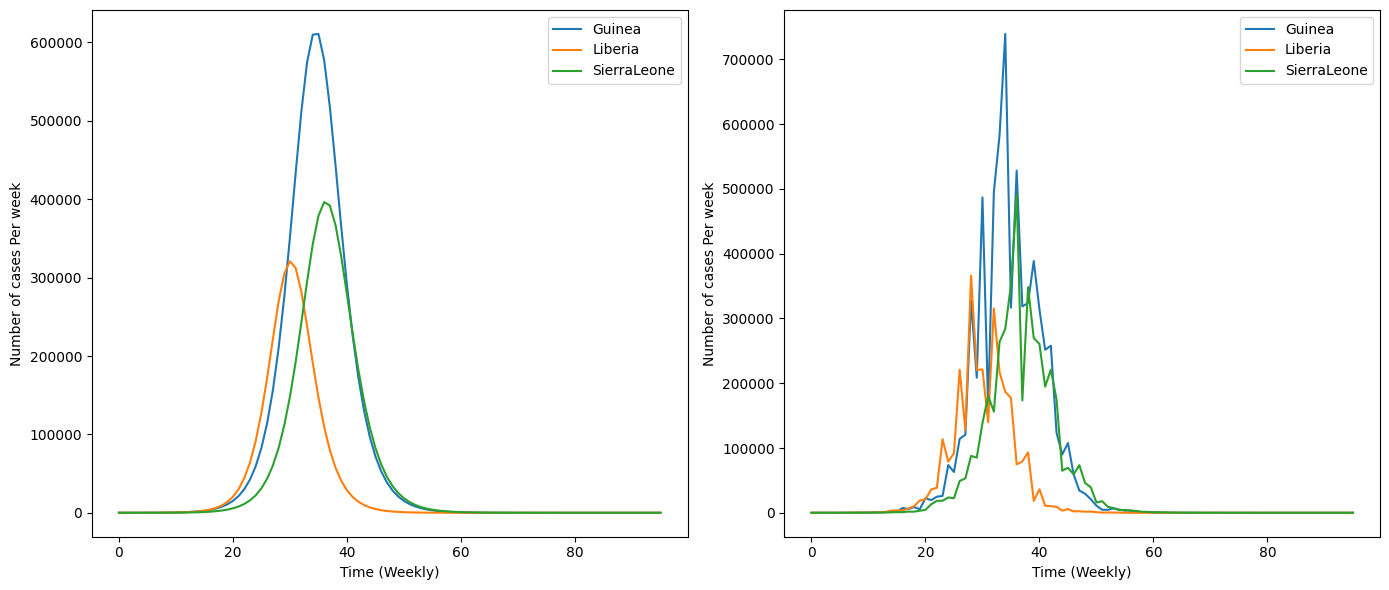

In [835]:
fig, ax = plt.subplots(1,2, figsize = (14, 6))
countries = ['Guinea', 'Liberia', 'SierraLeone']
for i in range(3):
    ax[0].plot(raw[f'{countries[i]}_New_case'])
    ax[0].legend(countries)
    # ax[0].set_title('Number of new infections NO NOISE at time t $[\int_0^T \sigma*$E]')
    ax[0].set_xlabel('Time (Weekly)')
    ax[0].set_ylabel('Number of cases Per week')

    ax[1].plot(raw[f'{countries[i]}_Noise'])
    ax[1].legend(countries)
    # ax[1].set_title('Number of new infections with NOISE at time t $[\int_0^T \sigma*$E]')
    ax[1].set_xlabel('Time (Weekly)')
    ax[1].set_ylabel('Number of cases Per week')

    # ax[2].plot(raw[f'C_{countries[i]}'])
    # ax[2].legend(countries)
    # ax[2].set_title('Number of Infections at time t [$ \sigma$ * E]')
    # ax[2].set_xlabel('Time (Weekly)')
    # ax[2].set_ylabel('Number of cases per week')

plt.tight_layout()
plt.savefig('images/generated_no_coupling.pdf')
plt.show()

In [825]:
# Plot for each country
countries = ['Guinea', 'Liberia', 'SierraLeone']
def plot_SEIR(df, country_name, Death = False, save=False, yscale = False):
    # Extract data for the current country
    S = df[f'S_{country_name}']
    E = df[f'E_{country_name}']
    I = df[f'I_{country_name}']
    R = df[f'R_{country_name}']

    # Create plot
    plt.figure(figsize=(13, 6))
    plt.plot(df['Day'], S, label='Susceptible', color='blue')
    plt.plot(df['Day'], E, label='Exposed', color='orange')
    plt.plot(df['Day'], I, label='Infective', color='red')
    plt.plot(df['Day'], R, label='Removed', color='green')
    if Death:
        D = df[f'D_{country_name}']
        plt.plot(df['Day'], D, label='Death', color='black')

    # Customize the plot
    plt.xlabel('Day')
    plt.ylabel('Number of Individuals')
    plt.title(f'SEIRD Dynamics for {country_name}')
    plt.legend()
    plt.grid(True)
    if yscale:
        plt.yscale('symlog')  # Use symlog scale to handle large ranges
    if save:
        plt.savefig(f'seird_{country_name.lower()}.png')
    plt.show()

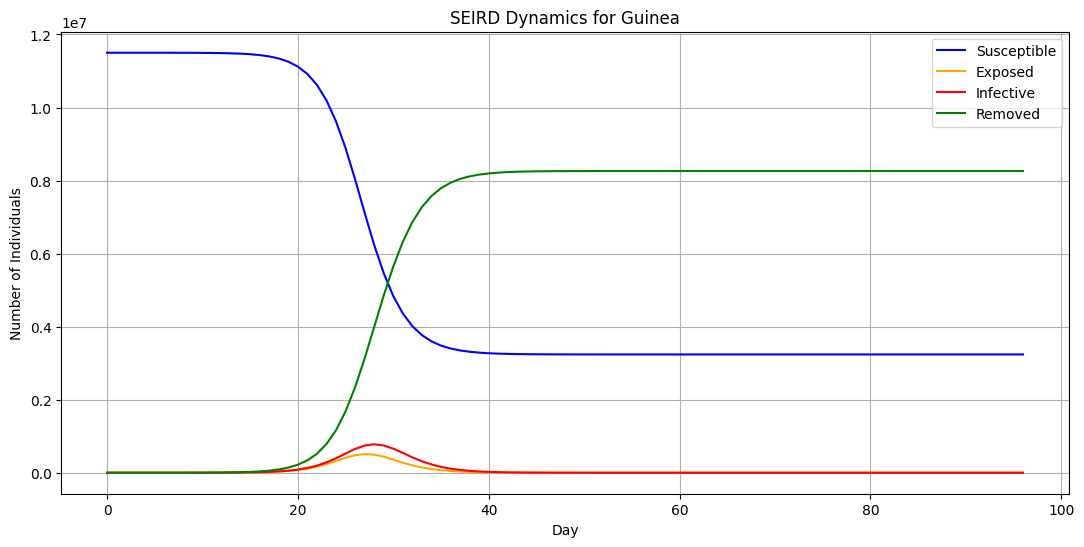

In [826]:
plot_SEIR(raw, 'Guinea')

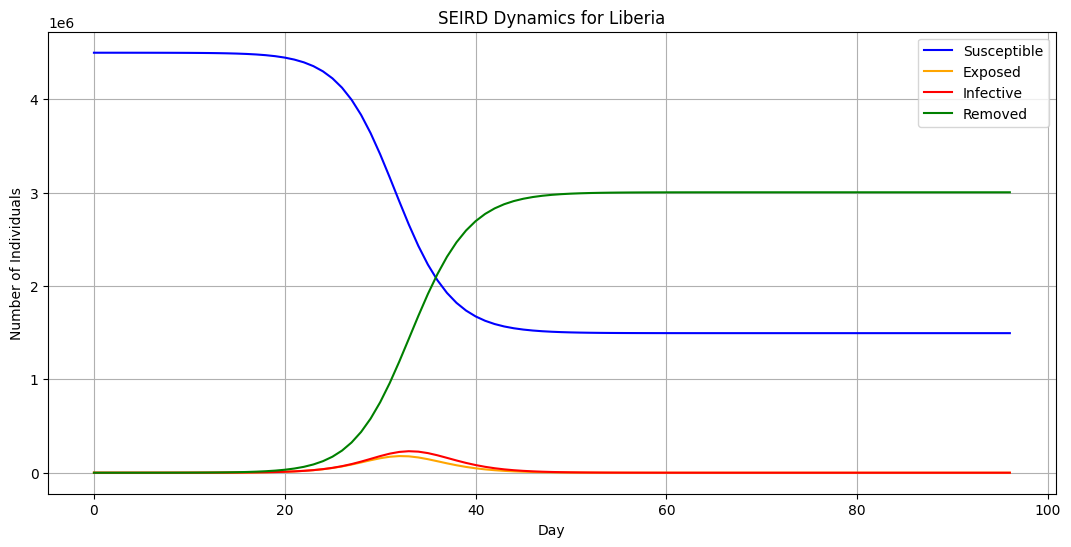

In [808]:
plot_SEIR(raw, 'Liberia')

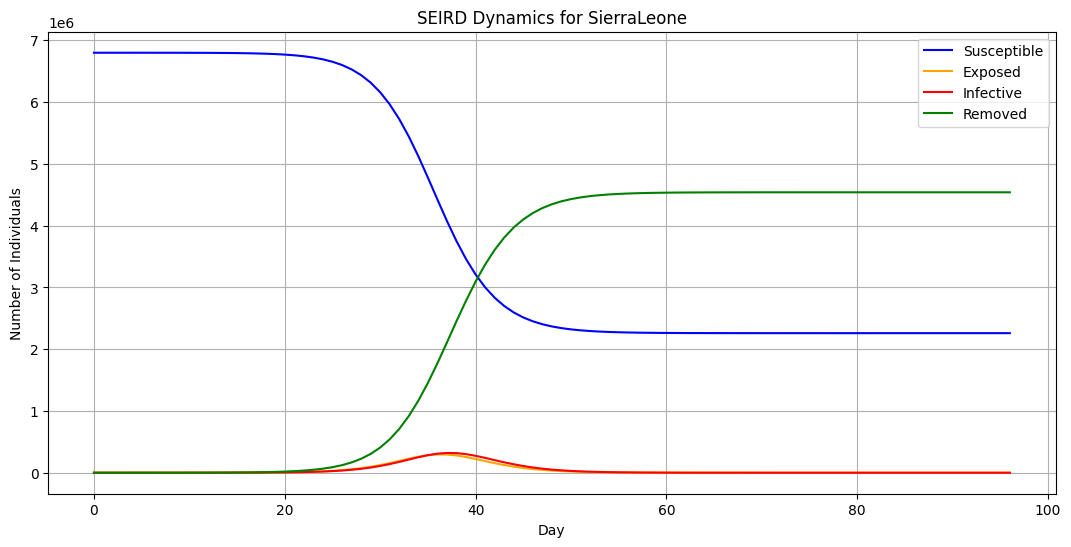

In [809]:
plot_SEIR(raw, 'SierraLeone')

# Create a function to plot Posterior for Parameters

# Fit the Model to daily cases


In [839]:
# Aggregate cases by country and week
countries = ['Guinea', 'Liberia', 'Sierra Leone']
# weekly_cases = df.groupby(['country', pd.Grouper(key='time', freq='W')]).sum().unstack(fill_value=0).T
weekly_cases1 = raw['Guinea_Noise']
weekly_cases2 = raw['Liberia_Noise']
weekly_cases3 = raw['SierraLeone_Noise']

cases1 = weekly_cases1.values  # Shape: (T, 3)
cases2 = weekly_cases2.values  # Shape: (T, 3)
cases3 = weekly_cases3.values  # Shape: (T, 3)

N = np.array([11.5e6, 4.5e6, 6.8e6]) 
# N = np.array([110000, 440000, 680000]) 
# N=np.array([2e6, 1.5e6, 1e6])
# Set the population size
# N = n[0] #763

beta = np.array([0.25, 0.27, 0.26])*7  # Transmission rate per week (R0 = beta/gamma)
sigma = np.array([1/4, 1/5, 1/6])*7 #incubation rate per week
gamma = np.array([1/6.3, 1/6.6, 1/6.6])*7  

phi = 10           # Negative binomial dispersion parameter
reporting_rate = 1 

# Define initial conditions
i0 = [10, 10, 10]
e0 = [10, 1, 1]
s0 = N - i0 - e0
r0 = [0, 0, 0]
c0 = [0, 0, 0]
y1 = [s0[0], e0[0], i0[0], r0[0], c0[0]]
y2 = [s0[1], e0[1], i0[1], r0[1], c0[1]]
y3 = [s0[2], e0[2], i0[2], r0[2], c0[2]]


In [840]:

# Make the data struture
seir_data1 = {
    "n_days": len(cases1),
    "y0": y1,
    "t0": 0,
    "t": np.arange(1, len(cases1)+1),
    "N": int(N[0]),
    "cases": cases1,
    'beta_value': beta[0],
    'sigma_value': sigma[0],
    'gamma_value': gamma[0],
    "reporting_rate": reporting_rate
}

seir_data2 = {
    "n_days": len(cases2),
    "y0": y2,
    "t0": 0,
    "t": np.arange(1, len(cases2)+1),
    "N": int(N[1]),
    "cases": cases2,
    'beta_value': beta[1],
    'sigma_value': sigma[1],
    'gamma_value': gamma[1],
    "reporting_rate": reporting_rate
}
seir_data3 = {
    "n_days": len(cases3),
    "y0": y3,
    "t0": 0,
    "t": np.arange(1, len(cases3)+1),
    "N": int(N[2]),
    "cases": cases3,
    'beta_value': beta[2],
    'sigma_value': sigma[2],
    'gamma_value': gamma[2],
    "reporting_rate": reporting_rate
}

seir_incidence_model1 = CmdStanModel(stan_file = 'stan files/simple_seir.stan')
seir_incidence_model2 = CmdStanModel(stan_file = 'stan files/simple_seir.stan')
seir_incidence_model3 = CmdStanModel(stan_file = 'stan files/simple_seir.stan')

In [ ]:
fit1 = seir_incidence_model1.sample(data = seir_data1,
                                    #    iter_warmup= 500,
                                    iter_sampling = 2000,
                                    # parallel_chains=True,
                                    chains = 4,
                                    seed = 0)

chain 1 |          | 00:00 Status




In [ ]:
fit2 = seir_incidence_model2.sample(data = seir_data2,
                                   iter_sampling = 2000,
                                #    parallel_chains=True,
                                   chains = 4,
                                   seed = 2)

chain 1 |          | 00:00 Status







chain 1 |▎         | 00:26 Status







chain 1 |▋         | 00:51 Iteration:    1 / 3000 [  0%]  (Warmup)


chain 1 |▉         | 01:06 Iteration:  100 / 3000 [  3%]  (Warmup)


chain 1 |█▎        | 01:12 Iteration:  200 / 3000 [  6%]  (Warmup)


chain 1 |█▌        | 01:18 Iteration:  300 / 3000 [ 10%]  (Warmup)




chain 1 |█▉        | 01:33 Iteration:  400 / 3000 [ 13%]  (Warmup)


chain 1 |██▏       | 01:37 Iteration:  500 / 3000 [ 16%]  (Warmup)
chain 1 |██▌       | 01:42 Iteration:  600 / 3000 [ 20%]  (Warmup)


chain 1 |██▊       | 01:58 Iteration:  700 / 3000 [ 23%]  (Warmup)


chain 1 |███▏      | 02:02 Iteration:  800 / 3000 [ 26%]  (Warmup)

chain 1 |███▍      | 02:05 Iteration:  900 / 3000 [ 30%]  (Warmup)


chain 1 |████      | 02:22 Iteration: 1001 / 3000 [ 33%]  (Sampling)


chain 1 |████▍     | 02:27 Iteration: 1100 / 3000 [ 36%]  (Sampling)


chain 1 |█████     | 02:46 Iteration: 1300 / 3000 [ 43%]  (Sampling)


chain 1 |█████▎ 

In [ ]:
fit3 = seir_incidence_model3.sample(data = seir_data3,
                                   iter_sampling = 2000,
                                #    parallel_chains=True,
                                   chains = 4,
                                   seed = 0)

chain 1 |          | 00:00 Status





chain 1 |▎         | 00:45 Status



chain 1 |█▎        | 01:25 Iteration:  200 / 3000 [  6%]  (Warmup)

chain 1 |██▌       | 01:42 Iteration:  600 / 3000 [ 20%]  (Warmup)

chain 1 |███▍      | 01:52 Iteration:  900 / 3000 [ 30%]  (Warmup)

chain 1 |████▋     | 02:00 Iteration: 1200 / 3000 [ 40%]  (Sampling)

chain 1 |█████▎    | 02:14 Iteration: 1400 / 3000 [ 46%]  (Sampling)

chain 1 |██████▎   | 02:23 Iteration: 1700 / 3000 [ 56%]  (Sampling)

chain 1 |██████▉   | 02:38 Iteration: 1900 / 3000 [ 63%]  (Sampling)

chain 1 |███████▊  | 02:46 Iteration: 2200 / 3000 [ 73%]  (Sampling)



chain 1 |████████▊ | 03:03 Iteration: 2500 / 3000 [ 83%]  (Sampling)

chain 1 |██████████| 03:22 Iteration: 2900 / 3000 [ 96%]  (Sampling)



































































chain 1 |██████████| 11:57 Sampling completed                       
chain 2 |██████████| 11:57 Sampling completed                       
chain 3 |██████████| 11:

In [ ]:
print(fit3.diagnose())

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
The E-BFMI, 0.21, is below the nominal threshold of 0.30 which suggests that HMC may have trouble exploring the target distribution.
If possible, try to reparameterize the model.

Rank-normalized split effective sample size satisfactory for all parameters.

The following parameters had rank-normalized split R-hat greater than 1.01:
  sigma, beta, gamma, y[1,1], y[4,1], y[5,1], y[6,1], y[7,1], y[8,1], y[9,1], y[10,1], y[11,1], y[12,1], y[13,1], y[14,1], y[15,1], y[16,1], y[17,1], y[18,1], y[19,1], y[20,1], y[21,1], y[22,1], y[23,1], y[24,1], y[25,1], y[26,1], y[27,1], y[28,1], y[29,1], y[30,1], y[31,1], y[32,1], y[33,1], y[34,1], y[35,1], y[36,1], y[37,1], y[38,1], y[39,1], y[40,1], y[41,1], y[42,1], y[43,1], y[44,1], y[45,1], y[46,1], y[47,1], y[48,1], y[49,1], y[50

In [ ]:
fit1_summary = fit1.summary()
fit1_summary.filter(items=("sigma", "beta", "gamma", "recovery_time", "incubation_period", "R0", "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
sigma,0.768062,0.001914,0.101116,0.093473,0.628225,0.753189,0.960011,2975.74,3226.73,1.00170
beta,2.169130,0.002584,0.132157,0.124701,1.973240,2.157490,2.400690,2705.69,3179.62,1.00175
gamma,0.547998,0.000982,0.058602,0.054452,0.463550,0.541948,0.652950,4260.08,3216.89,1.00213
recovery_time,1.844880,0.002955,0.189903,0.185303,1.531510,1.845190,2.157260,4260.06,3216.89,1.00201
incubation_period,1.323340,0.003040,0.164897,0.164961,1.041650,1.327690,1.591780,2975.77,3226.73,1.00170
R0,3.996480,0.007301,0.434012,0.424698,3.307450,3.978840,4.730020,3496.31,3660.16,1.00095
phi,4.879540,0.017085,1.034760,1.019210,3.343340,4.792560,6.679320,3729.73,4116.47,1.00103
phi_inv,0.214423,0.000777,0.046793,0.043465,0.149716,0.208656,0.299102,3729.74,4116.47,1.00145


In [ ]:
fit2_summary = fit2.summary()
fit2_summary.filter(items=("sigma", "beta", "gamma", "recovery_time", "incubation_period", "R0", "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
sigma,0.694869,0.001519,0.051733,0.027848,0.643459,0.683850,0.796745,2066.21,1354.46,1.00209
beta,2.582400,0.002954,0.124747,0.128401,2.396370,2.570990,2.801270,1841.67,2867.76,1.00129
gamma,0.307601,0.002212,0.071598,0.046116,0.235379,0.283973,0.469280,1376.93,1580.20,1.00252
recovery_time,3.394670,0.018500,0.637050,0.597058,2.130930,3.521460,4.248470,1376.93,1580.20,1.00252
incubation_period,1.445900,0.002557,0.092017,0.060045,1.255110,1.462310,1.554090,2066.18,1354.46,1.00209
R0,8.705040,0.040227,1.365860,1.111540,5.814480,9.041500,10.411200,1449.76,1390.83,1.00219
phi,9.114100,0.050274,2.511810,2.440890,5.532560,8.777920,13.669000,2451.68,3376.58,1.00125
phi_inv,0.118437,0.000690,0.034051,0.031713,0.073158,0.113922,0.180748,2451.68,3376.58,1.00121


In [ ]:
fit3_summary = fit3.summary()
fit3_summary.filter(items=("sigma", "beta", "gamma", "recovery_time", "incubation_period", "R0", "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
sigma,0.845591,0.125140,0.213344,0.197614,0.540434,0.867344,1.188510,7.25220,4000.0000,1.52778
beta,2.416950,0.093151,0.195413,0.211196,2.133010,2.408970,2.753750,8.91282,40.2527,1.37024
gamma,0.537043,0.153967,0.223702,0.093949,0.146162,0.629435,0.766958,7.12439,4000.0000,1.52937
recovery_time,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
incubation_period,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
R0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
phi,8.852470,0.032324,2.144070,2.130960,5.716770,8.666240,12.689000,4412.07000,4208.1000,1.00079
phi_inv,0.119894,0.000466,0.030346,0.028182,0.078809,0.115390,0.174924,4412.07000,4208.1000,1.00079


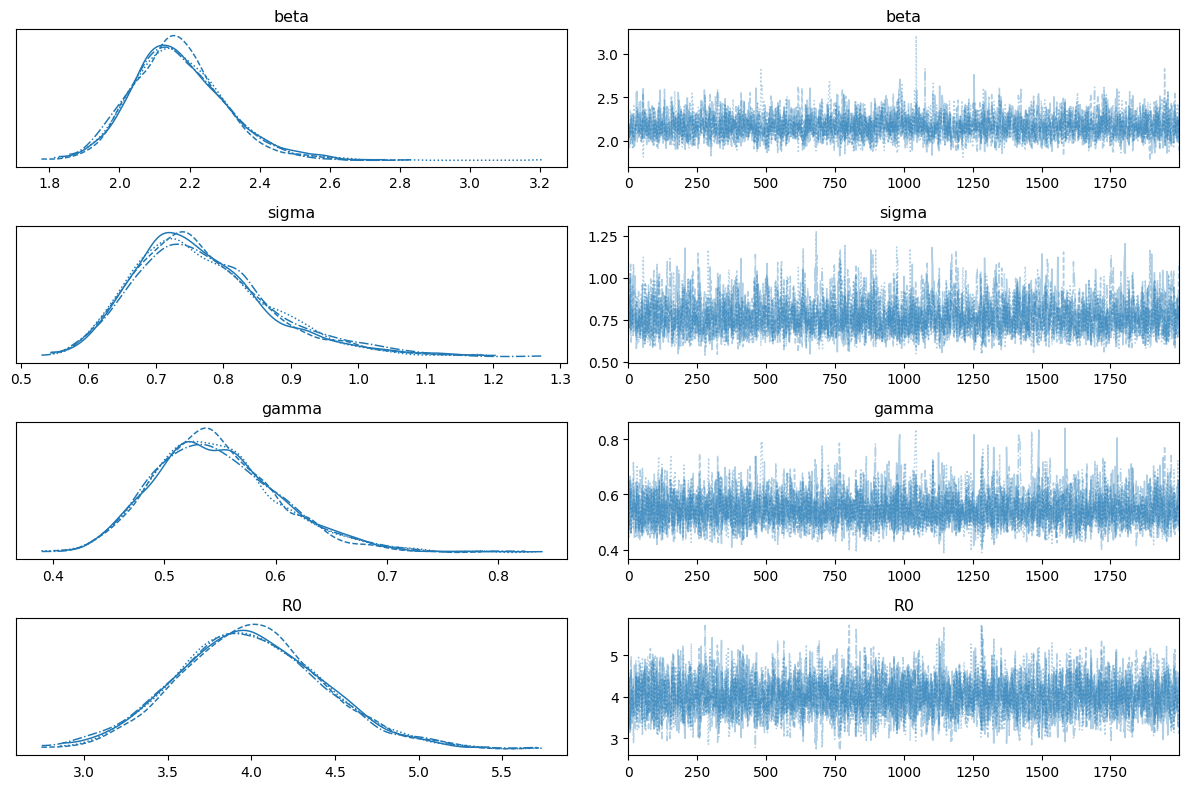

In [ ]:
## trace plots
az.plot_trace(fit1, var_names=["beta", "sigma", "gamma", "R0"])
plt.tight_layout()
plt.show()

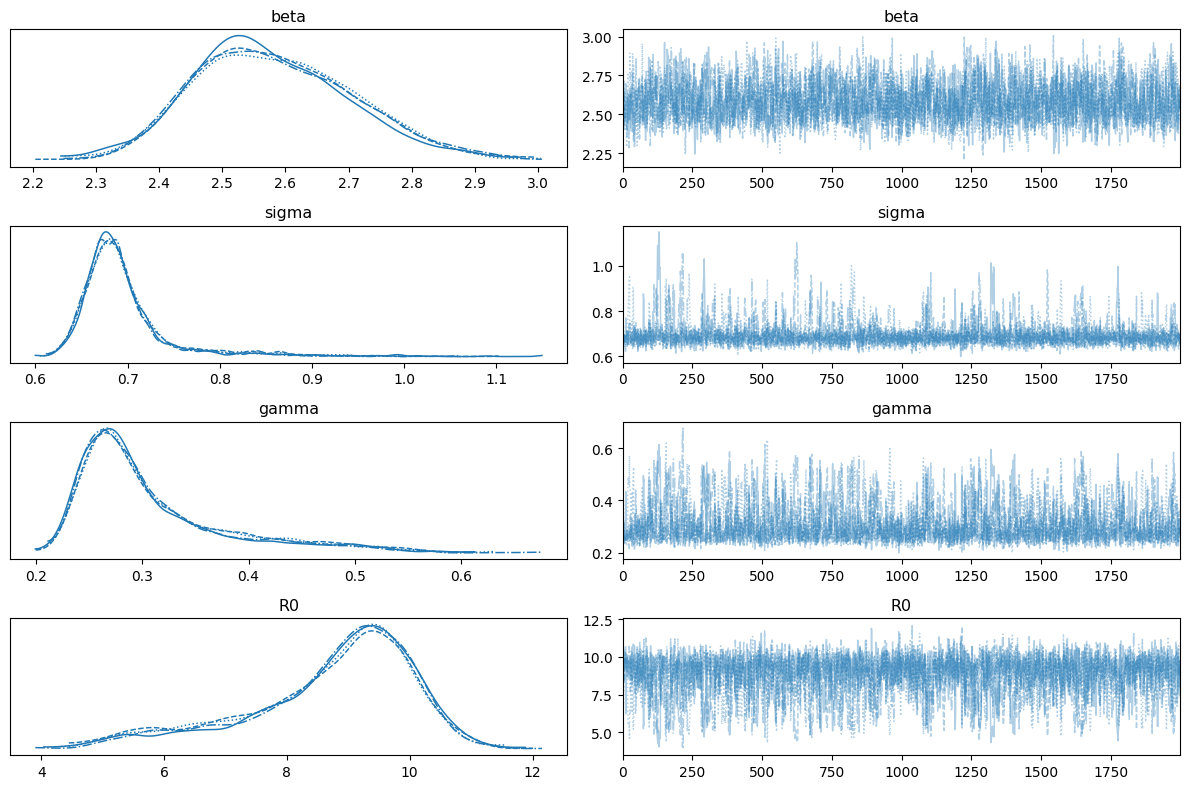

In [ ]:
az.plot_trace(fit2, var_names=["beta", "sigma", "gamma", "R0"])
plt.tight_layout()
plt.show()

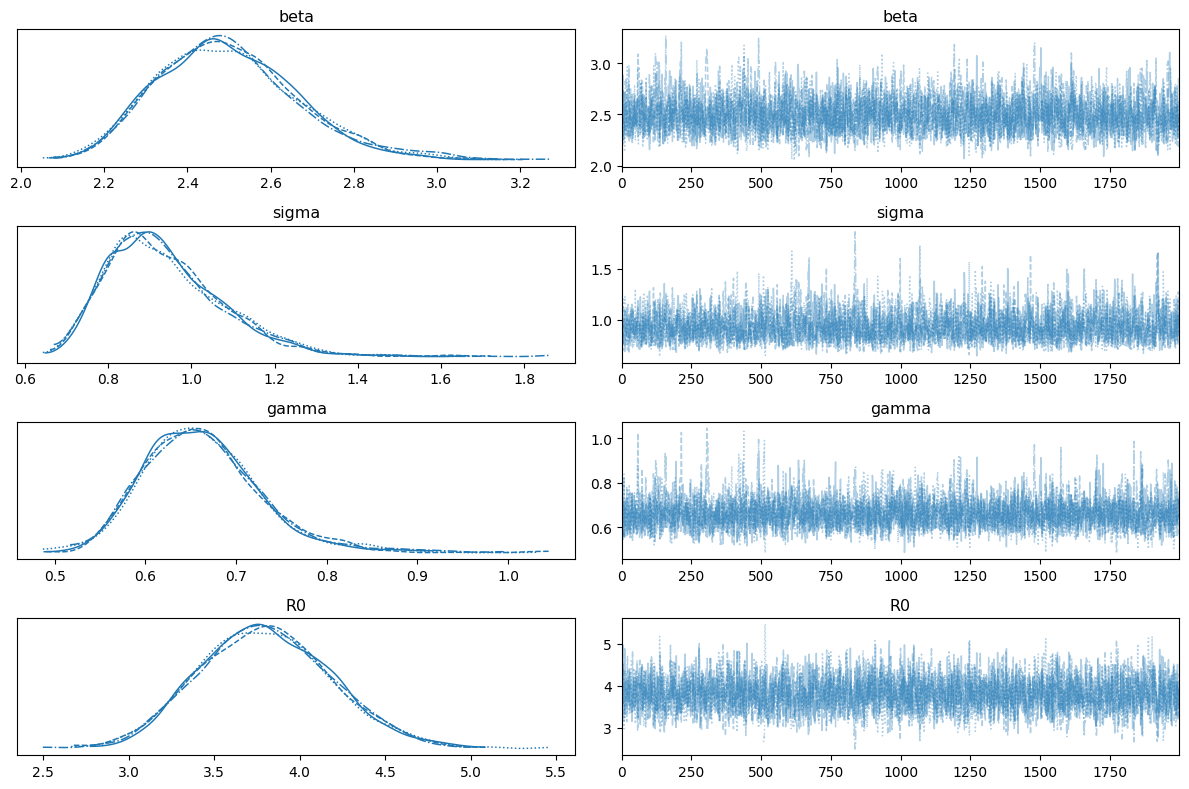

In [ ]:
az.plot_trace(fit3, var_names=["beta", "sigma", "gamma", "R0"])
plt.tight_layout()
plt.show()

In [ ]:
# Extract posterior samples
post_guinea = fit1.draws_pd()
post_liberia = fit2.draws_pd()
post_sierra = fit3.draws_pd()

## save the posterior samples
post_guinea.to_csv('./Data/posterior_samples_guinea.csv', index=False)
post_liberia.to_csv('./Data/posterior_samples_liberia.csv', index=False)
post_sierra.to_csv('./Data/posterior_samples_sierra.csv', index=False)

# Posterior Predictive Checks

In [ ]:
fit1_summary.filter(like="pred_incidence", axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
pred_incidence[1],12.9200,0.085522,7.15484,7.4130,3.0,12.0,26.0,7205.80,6915.28,1.000130
pred_incidence[2],25.8463,0.144758,12.97670,11.8608,9.0,24.0,50.0,8066.10,7834.94,1.000280
pred_incidence[3],48.8704,0.266742,23.78250,22.2390,17.0,45.0,94.0,7789.71,8089.55,0.999923
pred_incidence[4],93.2755,0.511064,44.91770,41.5128,33.0,86.0,175.0,7720.23,7692.00,0.999914
pred_incidence[5],173.3510,0.894588,81.64070,75.6126,65.0,161.0,324.0,8295.38,8153.45,1.000040
...,...,...,...,...,...,...,...,...,...,...
pred_incidence[92],0.0000,NaN,0.00000,0.0000,0.0,0.0,0.0,NaN,NaN,NaN
pred_incidence[93],0.0000,NaN,0.00000,0.0000,0.0,0.0,0.0,NaN,NaN,NaN
pred_incidence[94],0.0000,NaN,0.00000,0.0000,0.0,0.0,0.0,NaN,NaN,NaN
pred_incidence[95],0.0000,NaN,0.00000,0.0000,0.0,0.0,0.0,NaN,NaN,NaN


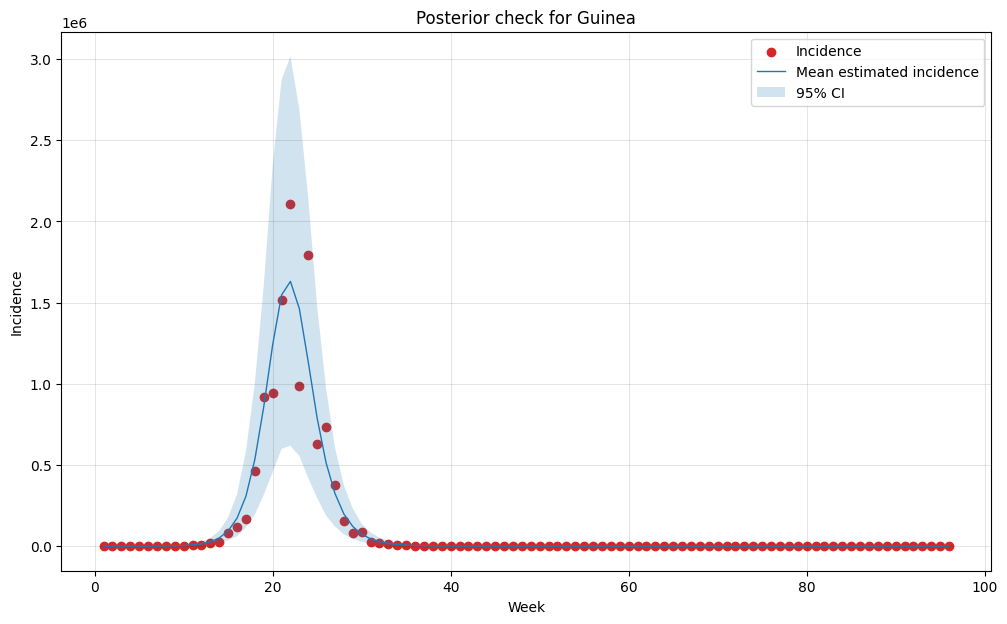

In [ ]:
post_pred1 = pd.DataFrame(fit1_summary.filter(like="pred_incidence", axis=0))
post_pred1["t"] = range(1, T+1)
post_pred1["incidence"] = list(cases1)
post_pred1 = post_pred1.set_index("t")

plt.figure(figsize=(12, 7))
plt.grid(True, which='both', color = 'k', alpha = 0.1)
plt.title(f'Posterior check for Guinea')
plt.ylabel('Incidence')
plt.xlabel('Week')
plt.scatter(x = post_pred1.index, y = post_pred1.incidence, color = 'tab:red', label = "Incidence")
plt.plot(post_pred1.Mean, color = 'tab:blue', linewidth= 1, label = "Mean estimated incidence")
plt.fill_between(x = post_pred1.index, y1 = post_pred1['5%'], y2 = post_pred1['95%'], alpha=0.2, label="95% CI")
# plt.facecolor('white')
plt.legend(loc = "upper right")

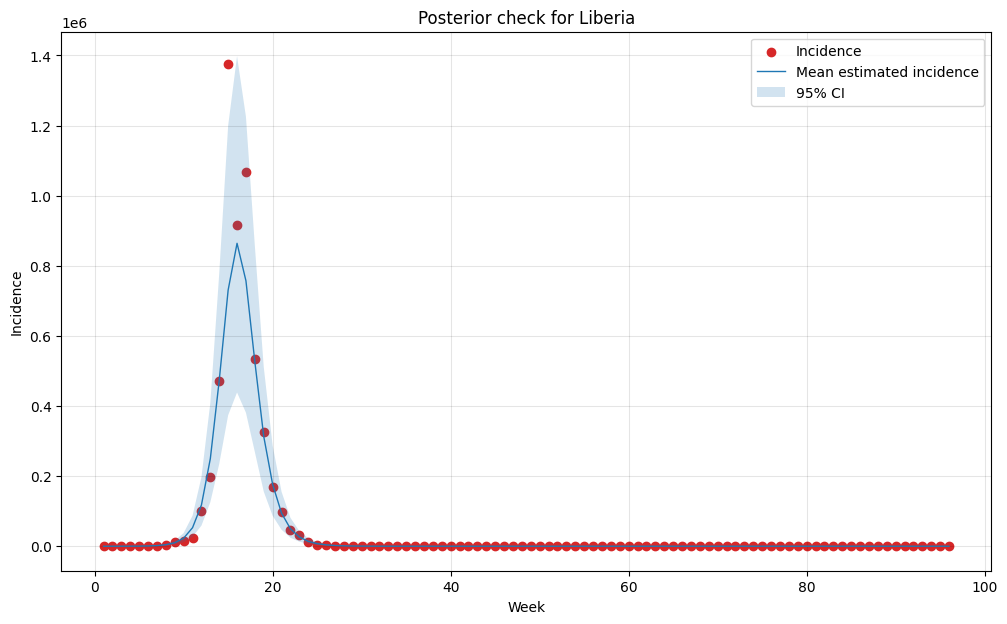

In [ ]:
post_pred2 = pd.DataFrame(fit2_summary.filter(like="pred_incidence", axis=0))
post_pred2["t"] = range(1, T+1)
post_pred2["incidence"] = list(cases2)
post_pred2 = post_pred2.set_index("t")

plt.figure(figsize=(12, 7))
plt.grid(True, which='both', color = 'k', alpha = 0.1)
plt.title(f'Posterior check for Liberia')
plt.ylabel('Incidence')
plt.xlabel('Week')
plt.scatter(x = post_pred2.index, y = post_pred2.incidence, color = 'tab:red', label = "Incidence")
plt.plot(post_pred2.Mean, color = 'tab:blue', linewidth= 1, label = "Mean estimated incidence")
plt.fill_between(x = post_pred2.index, y1 = post_pred2['5%'], y2 = post_pred2['95%'], alpha=0.2, label="95% CI")
# plt.facecolor('white')
plt.legend(loc = "upper right")

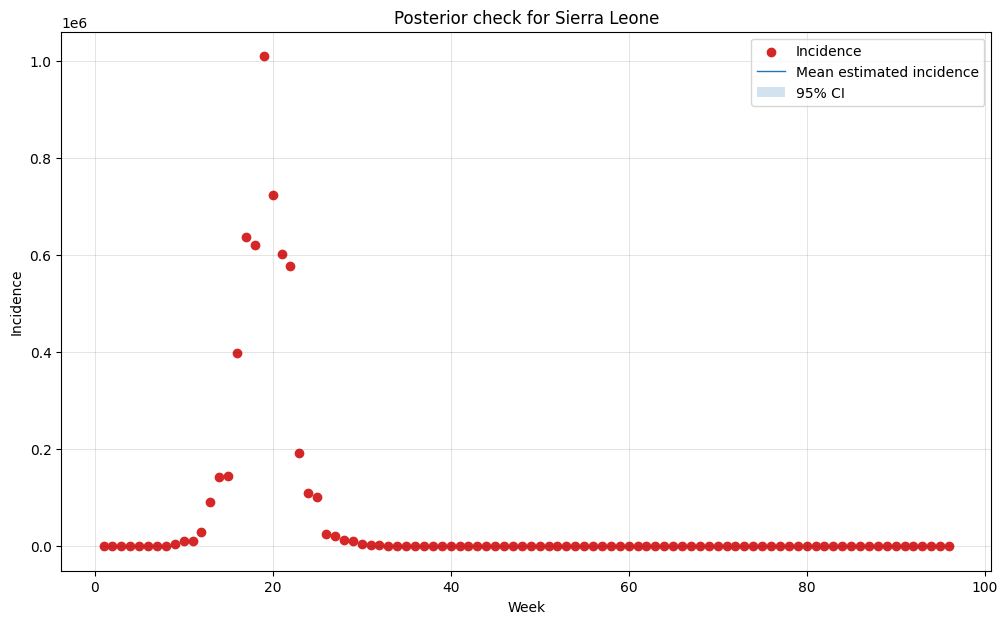

In [ ]:
post_pred3 = pd.DataFrame(fit3_summary.filter(like="pred_incidence", axis=0))
post_pred3["t"] = range(1, T+1)
post_pred3["incidence"] = list(cases3)
post_pred3 = post_pred3.set_index("t")

plt.figure(figsize=(12, 7))
plt.grid(True, which='both', color = 'k', alpha = 0.1)
plt.title(f'Posterior check for Sierra Leone')
plt.ylabel('Incidence')
plt.xlabel('Week')
plt.scatter(x = post_pred3.index, y = post_pred3.incidence, color = 'tab:red', label = "Incidence")
plt.plot(post_pred3.Mean, color = 'tab:blue', linewidth= 1, label = "Mean estimated incidence")
plt.fill_between(x = post_pred3.index, y1 = post_pred3['5%'], y2 = post_pred3['95%'], alpha=0.2, label="95% CI")
# plt.facecolor('white')
plt.legend(loc = "upper right")

In [ ]:
# Assuming `fit` is your CmdStanMCMC object from fitting the model
parameters1 = ["beta", "sigma", "recovery_time", "gamma", "incubation_period", "R0","phi"]

beta = np.array([0.25, 0.27, 0.26])*7  # Transmission rate per week (R0 = beta/gamma)
sigma = np.array([1/4, 1/5, 1/6])*7 #incubation rate per week
gamma = np.array([1/6.3, 1/6.6, 1/6.6])*7  

phi = 10           # Negative binomial dispersion parameter
reporting_rate = 1 #0.8  # Proportion of cases reported
r = beta/(gamma)
rec = 1.0/gamma
incu = 1.0 / sigma

t1 = {'beta':beta[0],'sigma': sigma[0], 'gamma': gamma[0], 'phi': phi ,
    'reporting_rate':reporting_rate, 'R0': r[0], 'recovery_time':rec[0],
    'incubation_period': incu[0]}

t2 = {'beta':beta[1],'sigma': sigma[1], 'gamma': gamma[1], 'phi': phi ,
    'reporting_rate':reporting_rate, 'R0': r[1], 'recovery_time':rec[1],
    'incubation_period': incu[1]}

t3 = {'beta':beta[2],'sigma': sigma[2], 'gamma': gamma[2], 'phi': phi ,
    'reporting_rate':reporting_rate, 'R0': r[2], 'recovery_time':rec[2],
    'incubation_period': incu[2]}

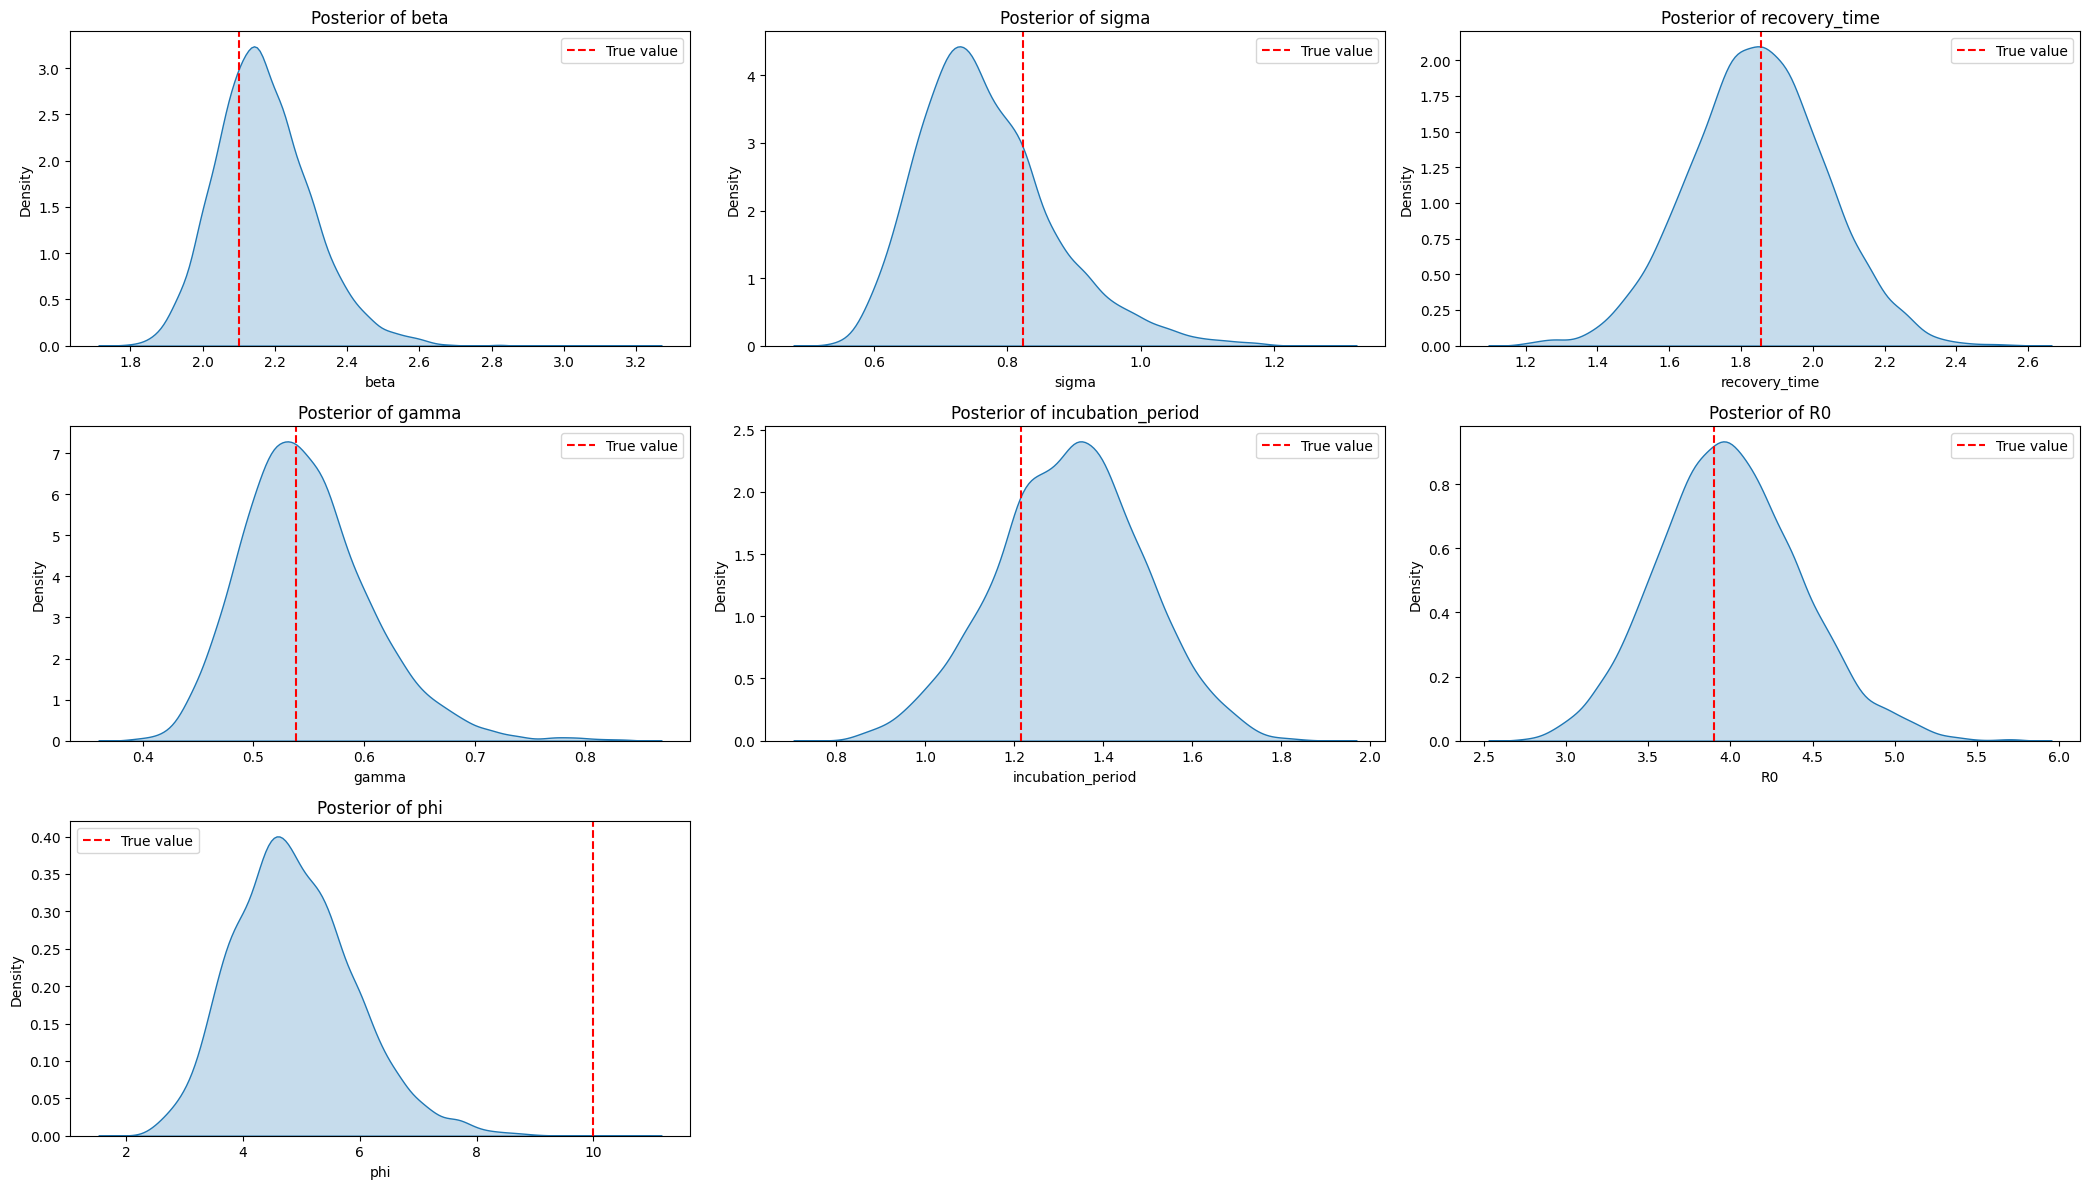

In [ ]:
from posterior_plot import plot_posterior_kde_grid

plot_posterior_kde_grid(fit1, parameters1, 3,t1, save = 'Checks_for_Guinea')

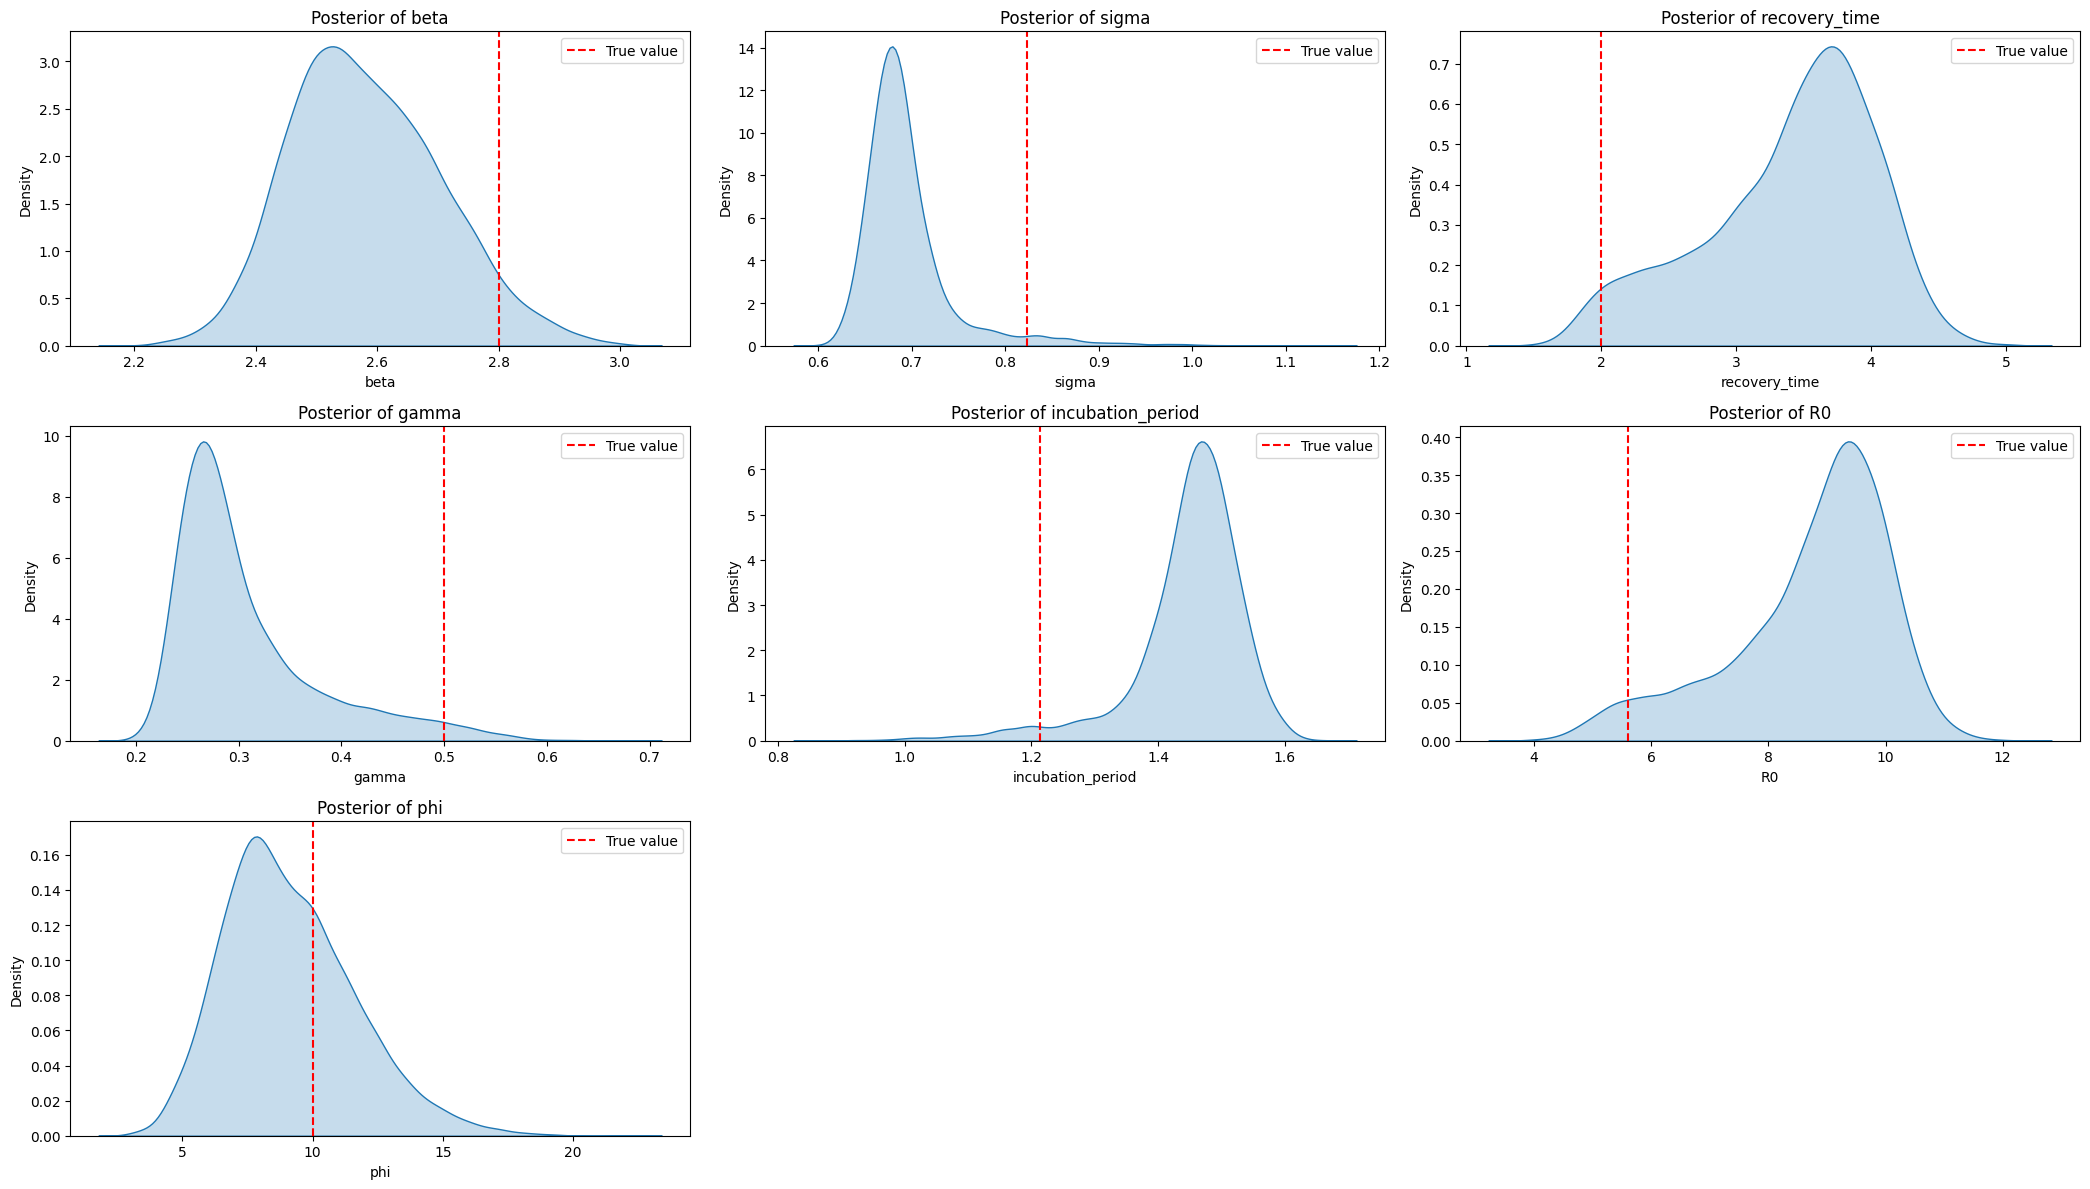

In [ ]:
plot_posterior_kde_grid(fit2, parameters1, 3,t2, save = 'Checks_for_Liberia')

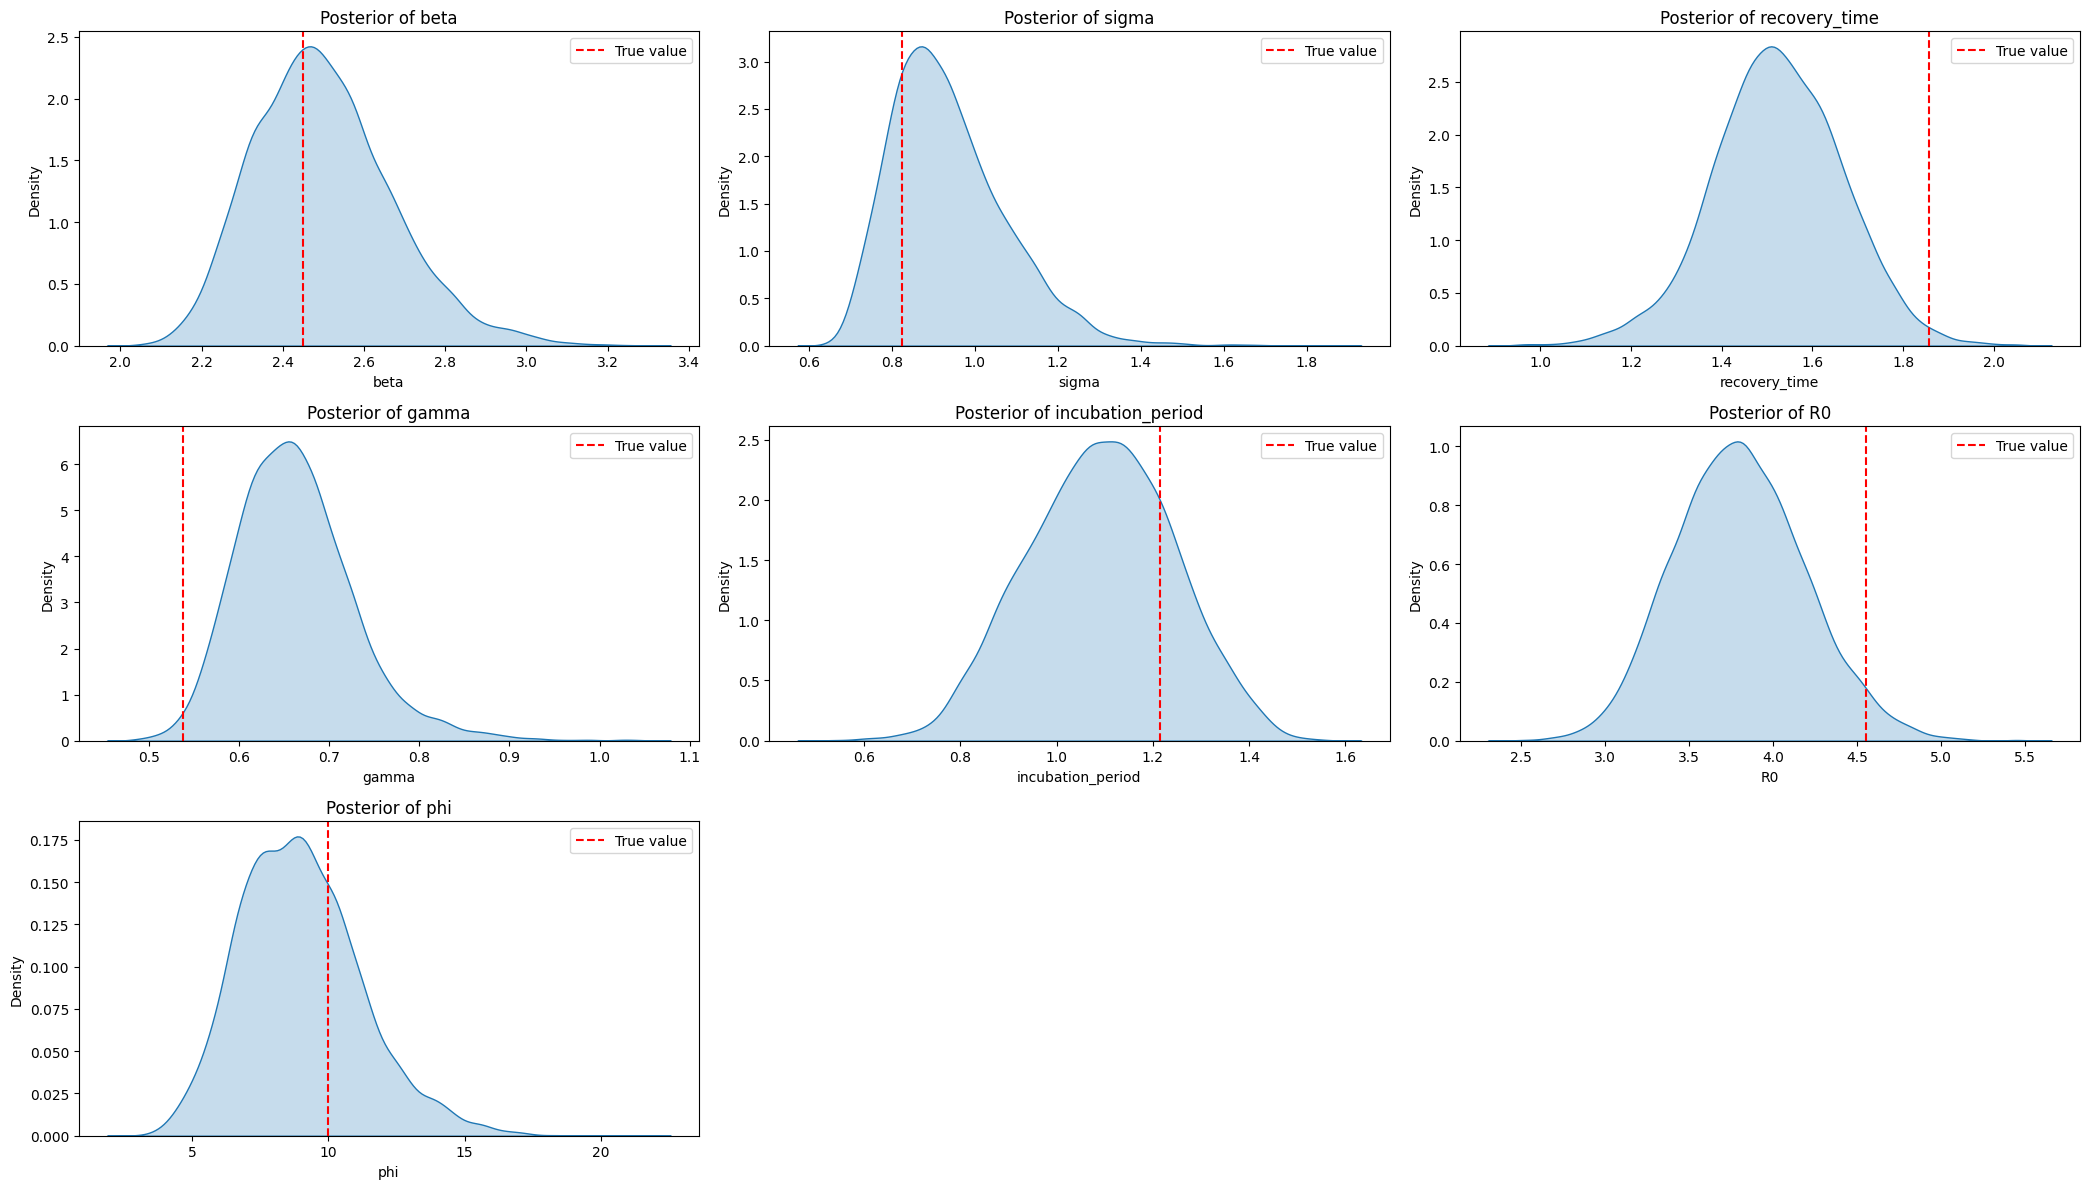

In [ ]:
plot_posterior_kde_grid(fit3, parameters1, 3,t3, save = 'Checks_for_Sierra_Leone')

## Plot SEIR Compartments

In [ ]:

def plot_compartment(fit, country_idx):
    # Time points and countries
    weeks = np.arange(fit.stan_variable('incidence').shape[1])  # Number of weeks
    countries = ['Guinea', 'Liberia', 'Sierra Leone']

    # Plot incidence (infectious) and reconstructed other compartments
    # for i in range(countries):
    # Create figure
    plt.figure(figsize=(12, 7))
    incidence = np.mean(fit.stan_variable('incidence'), axis=0)

    # Reconstruct approximate compartments (scaled by reporting rate)
    I = incidence
    R = np.cumsum(I) * np.mean(fit.stan_variable('gamma'))
    E = np.roll(I, 1) / np.mean(fit.stan_variable('sigma'))  # Exposed ~ delayed infectious
    # E[0] = 0
    S = N[country_idx] - E - I - R

    # Convert to fractions
    S_frac = S / N[country_idx]
    E_frac = E / N[country_idx]
    I_frac = I / N[country_idx]
    R_frac = R / N[country_idx]

    # Plot
    plt.plot(weeks, S_frac, 'b', label='Susceptible')
    plt.plot(weeks, E_frac, 'y', label='Exposed')
    plt.plot(weeks, I_frac, 'r', label='Infectious')
    plt.plot(weeks, R_frac, 'g', label='Recovered')

    # Formatting
    plt.title(f'{countries[country_idx]} (R0={np.mean(fit.stan_variable("R0")):.2f})')
    plt.ylabel('Fraction of Population')
    plt.grid(True, alpha=0.3)
    # ax.set_ylim(0, 1)

    plt.legend(loc='upper right')
    plt.xlabel('Weeks since outbreak start')
    # plt.tight_layout()
    plt.show()                                                                                      

In [ ]:
# plot_compartment(fit_seir_incidence_model, country_idx=0)
# plot_compartment(fit2, country_idx=1)
# plot_compartment(fit3, country_idx=2)

# FITTING FOR 3 PATCHES

In [ ]:
weekly = raw[['Guinea_Noise', 'Liberia_Noise', 'SierraLeone_Noise']]
weekly.head()

,Guinea_Noise,Liberia_Noise,SierraLeone_Noise
0,0,0,0
1,8,18,19
2,23,53,66
3,79,97,58
4,97,227,127


In [ ]:

N = np.array([11.5e6, 4.5e6, 6.8e6]) 
# N = np.array([2e6, 1.5e6, 1e6])
# N = np.array([110000, 440000, 680000])
# Set the population size

# Define initial conditions
g0 = [N[0]-10, 10, 10, 0, 0]
l0 = [N[1]-10, 10, 1, 0, 0]
s0 = [N[2]-10, 10, 1, 0, 0]

ts = weekly.values.T
y0 = [g0, l0, s0]

beta = np.array([0.25, 0.27, 0.26])*7  # Transmission rate per week (R0 = beta/gamma)
sigma = np.array([1/4, 1/5, 1/6])*7 #incubation rate per week
gamma = np.array([1/6.3, 1/6.6, 1/6.6])*7  

phi = 10           # Negative binomial dispersion parameter
reporting_rate = 1  

# Make the data struture
seir_data = {
    'N_countries': 3,
    "n_weeks": len(ts[0]),
    'y0': y0,
    't0': 0,
    "t": np.arange(1, len(ts[0])+1),
    "N": N.astype(int),
    "cases": ts,
    'beta_values': beta,
    'sigma_values': sigma,
    'gamma_values': gamma,
    'reporting_rate': reporting_rate
}

multi_model = CmdStanModel(stan_file = 'stan files/mult.stan')

In [ ]:
fit_multi_model = multi_model.sample(data = seir_data,
                                     iter_sampling = 1000,
                                     parallel_chains=True,
                                     chains = 4,
                                     seed = 0)

chain 1 |          | 00:00 Status


chain 1 |██████████| 00:00 Sampling completed
chain 2 |██████████| 00:00 Sampling completed

chain 3 |██████████| 00:00 Sampling completed


chain 4 |██████████| 00:00 Sampling completed

RuntimeError: Error during sampling:
Exception: tmpef0uzvki_model_namespace::log_prob: phi is nan, but must be greater than or equal to 0.000000 (in 'mult.stan', line 49, column 2 to column 20)
	Exception: tmpef0uzvki_model_namespace::log_prob: phi is nan, but must be greater than or equal to 0.000000 (in 'mult.stan', line 49, column 2 to column 20)
	Exception: tmpef0uzvki_model_namespace::log_prob: phi is nan, but must be greater than or equal to 0.000000 (in 'mult.stan', line 49, column 2 to column 20)
	Exception: tmpef0uzvki_model_namespace::log_prob: phi is nan, but must be greater than or equal to 0.000000 (in 'mult.stan', line 49, column 2 to column 20)
	Exception: tmpef0uzvki_model_namespace::log_prob: phi is nan, but must be greater than or equal to 0.000000 (in 'mult.stan', line 49, column 2 to column 20)
	Exception: tmpef0uzvki_model_namespace::log_prob: phi is nan, but must be greater than or equal to 0.000000 (in 'mult.stan', line 49, column 2 to column 20)
	Exception: tmpe

In [ ]:
print(fit_multi_model.diagnose())

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [ ]:
multy_fit_summary = fit_multi_model.summary()
multy_fit_summary.filter(items=("beta[1]","beta[2]", "beta[3]", "sigma", "recovery_time",
                                 "gamma", "incubation_period", "R0[1]","R0[2]", "R0[3]",
                                   "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
beta[1],1.885630,0.004056,0.250185,0.246771,1.526210,1.855620,2.332290,4148.72,2508.59,1.00024
beta[2],2.576200,0.003592,0.225291,0.212983,2.242040,2.556660,2.976690,4241.10,3084.23,1.00392
beta[3],2.223900,0.004070,0.247477,0.239195,1.874870,2.197870,2.669390,4078.88,2577.14,1.00219
R0[1],2.689930,0.006674,0.432196,0.415002,2.088880,2.633940,3.469550,4347.45,3106.04,1.00053
R0[2],3.169770,0.006522,0.431935,0.410428,2.552460,3.131120,3.940630,4620.08,2900.41,1.00035
R0[3],2.347150,0.004116,0.283593,0.277884,1.944400,2.314890,2.861190,4879.20,2645.88,1.00203
phi,6.234070,0.013313,0.959251,0.951125,4.760100,6.185530,7.918790,5360.60,3023.43,1.00083
phi_inv,0.164252,0.000356,0.025544,0.024791,0.126282,0.161668,0.210079,5360.40,3023.43,1.00064


In [ ]:
# # Extract posterior samples
# post_no = fit_multi_model.draws_pd()

# ## save the posterior samples
# post_no.to_csv('./Data/posterior_samples_no_coupling.csv', index=False)

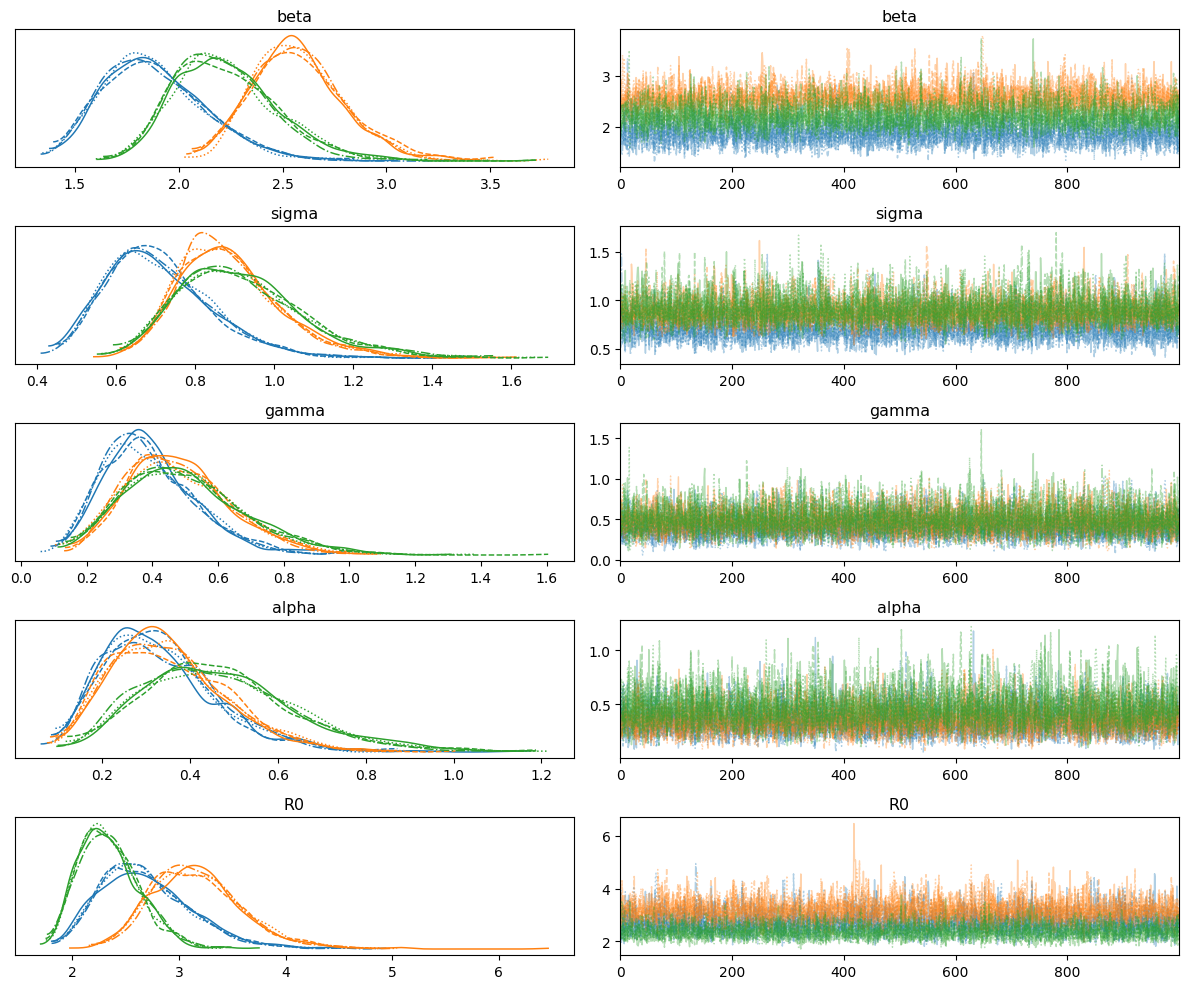

In [ ]:

az.plot_trace(fit_multi_model, var_names=["beta", "sigma", "gamma", "R0"])
plt.tight_layout()
plt.show()

# POSTERIOR PREDICTIVE CHECK

In [ ]:
# Get available variables
# Assuming `fit` is your CmdStanMCMC object from fitting the model
posterior_samples = fit_multi_model.draws_pd()  # returns a pandas DataFrame

beta = np.array([0.25, 0.27, 0.26])*7  # Transmission rate per week (R0 = beta/gamma)
sigma = np.array([1/4, 1/5, 1/6])*7 #incubation rate per week
gamma = np.array([1/6.3, 1/6.6, 1/6.6])*7    # 1/infectious period (Ebola: ~7 days)

phi = 10            # Negative binomial dispersion parameter
reporting_rate = 1
r = beta/gamma
rec = 1.0/gamma
incu = 1.0 / sigma

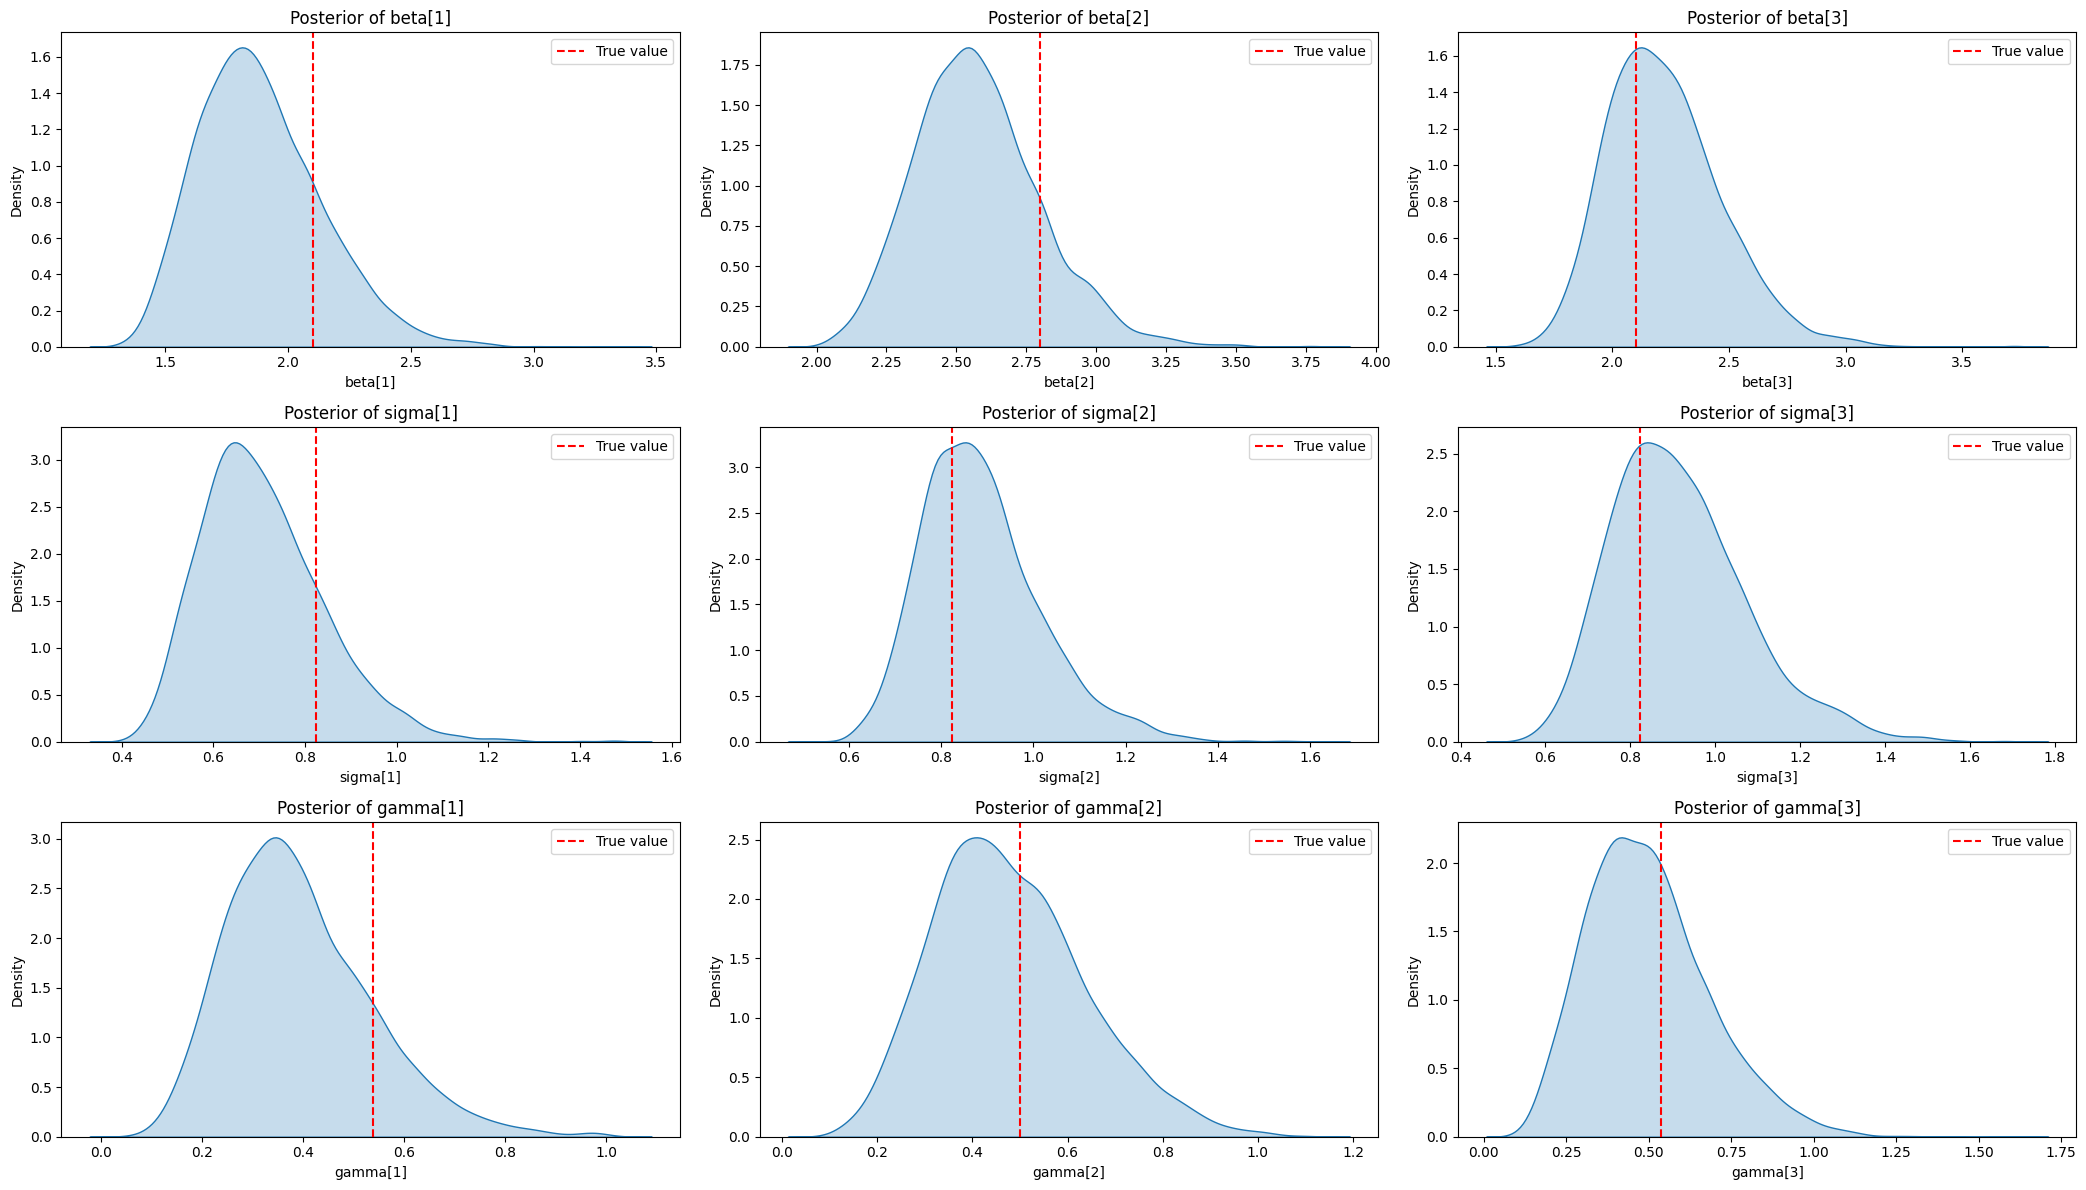

In [ ]:
parameters = ["beta[1]","beta[2]", "beta[3]", 
                "sigma[1]","sigma[2]","sigma[3]", 
                "gamma[1]","gamma[2]","gamma[3]"]
                
t = {'beta[1]': beta[0], 'beta[2]': beta[1], 'beta[3]': beta[2],
    'sigma[1]': sigma[0], 'sigma[2]': sigma[1], 'sigma[3]': sigma[2],   
    'gamma[1]': gamma[0], 'gamma[2]': gamma[1], 'gamma[3]': gamma[2],
    'phi': phi , 'reporting_rate':1}

plot_posterior_kde_grid(fit_multi_model, parameters=parameters, n_cols=3, true_values=t, save = 'Checks_for_betaGammaSigma')

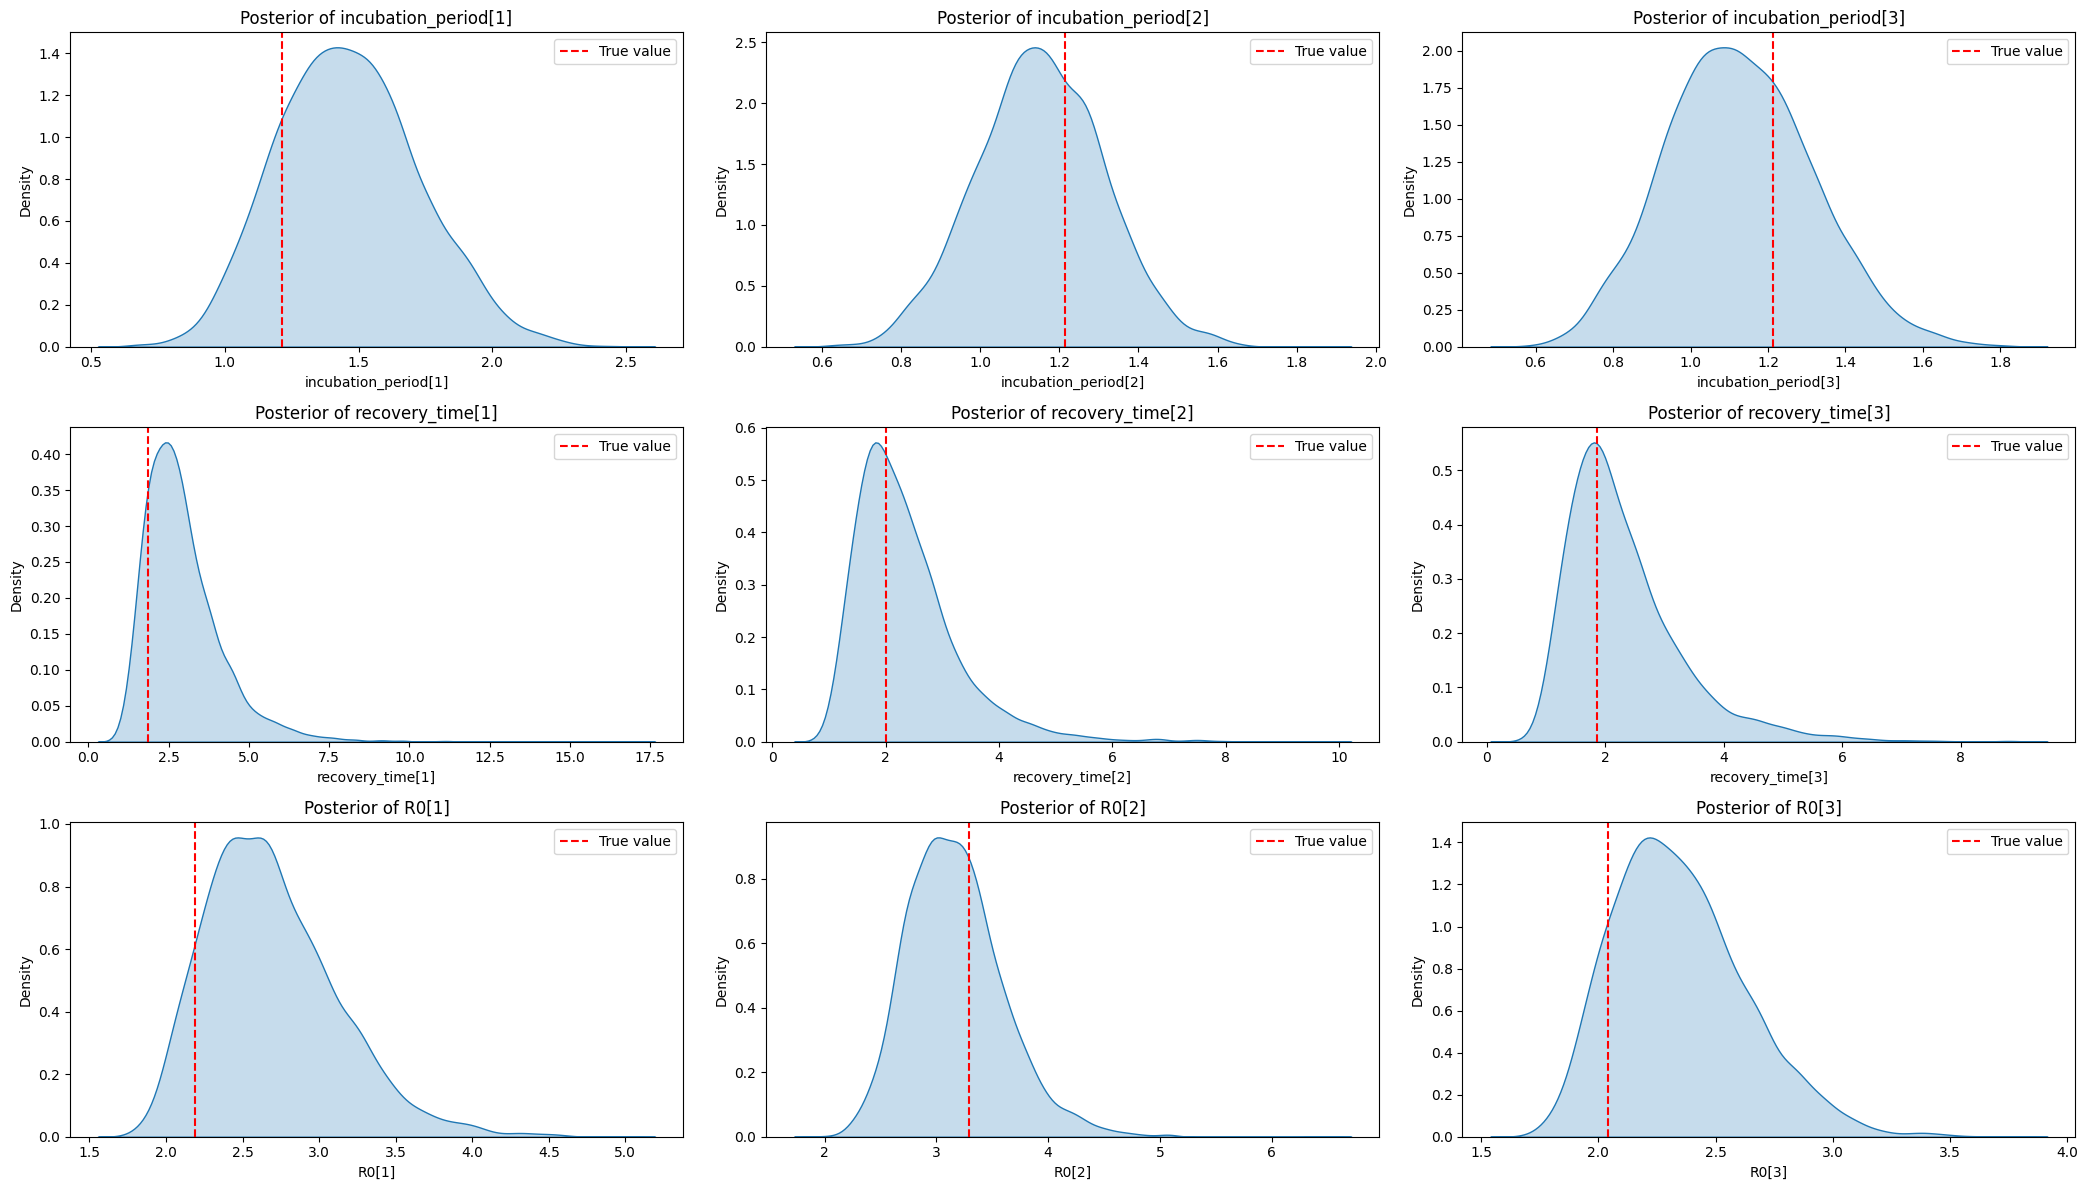

In [ ]:
parameters1 = ["incubation_period[1]","incubation_period[2]","incubation_period[3]", 
                "recovery_time[1]","recovery_time[2]","recovery_time[3]",
                "R0[1]","R0[2]", "R0[3]"]
t1 = {
    'R0[1]': r[0], 'R0[2]': r[1], 'R0[3]': r[2], 
    'recovery_time[1]':rec[0],
    'recovery_time[2]':rec[1],
    'recovery_time[3]':rec[2],
    'incubation_period[1]': incu[0],
    'incubation_period[2]': incu[1],
    'incubation_period[3]': incu[2]}


plot_posterior_kde_grid(fit_multi_model, parameters=parameters1, 
                        n_cols=3, true_values=t1, save = 'Checks_for_recoveryIncubationR0')

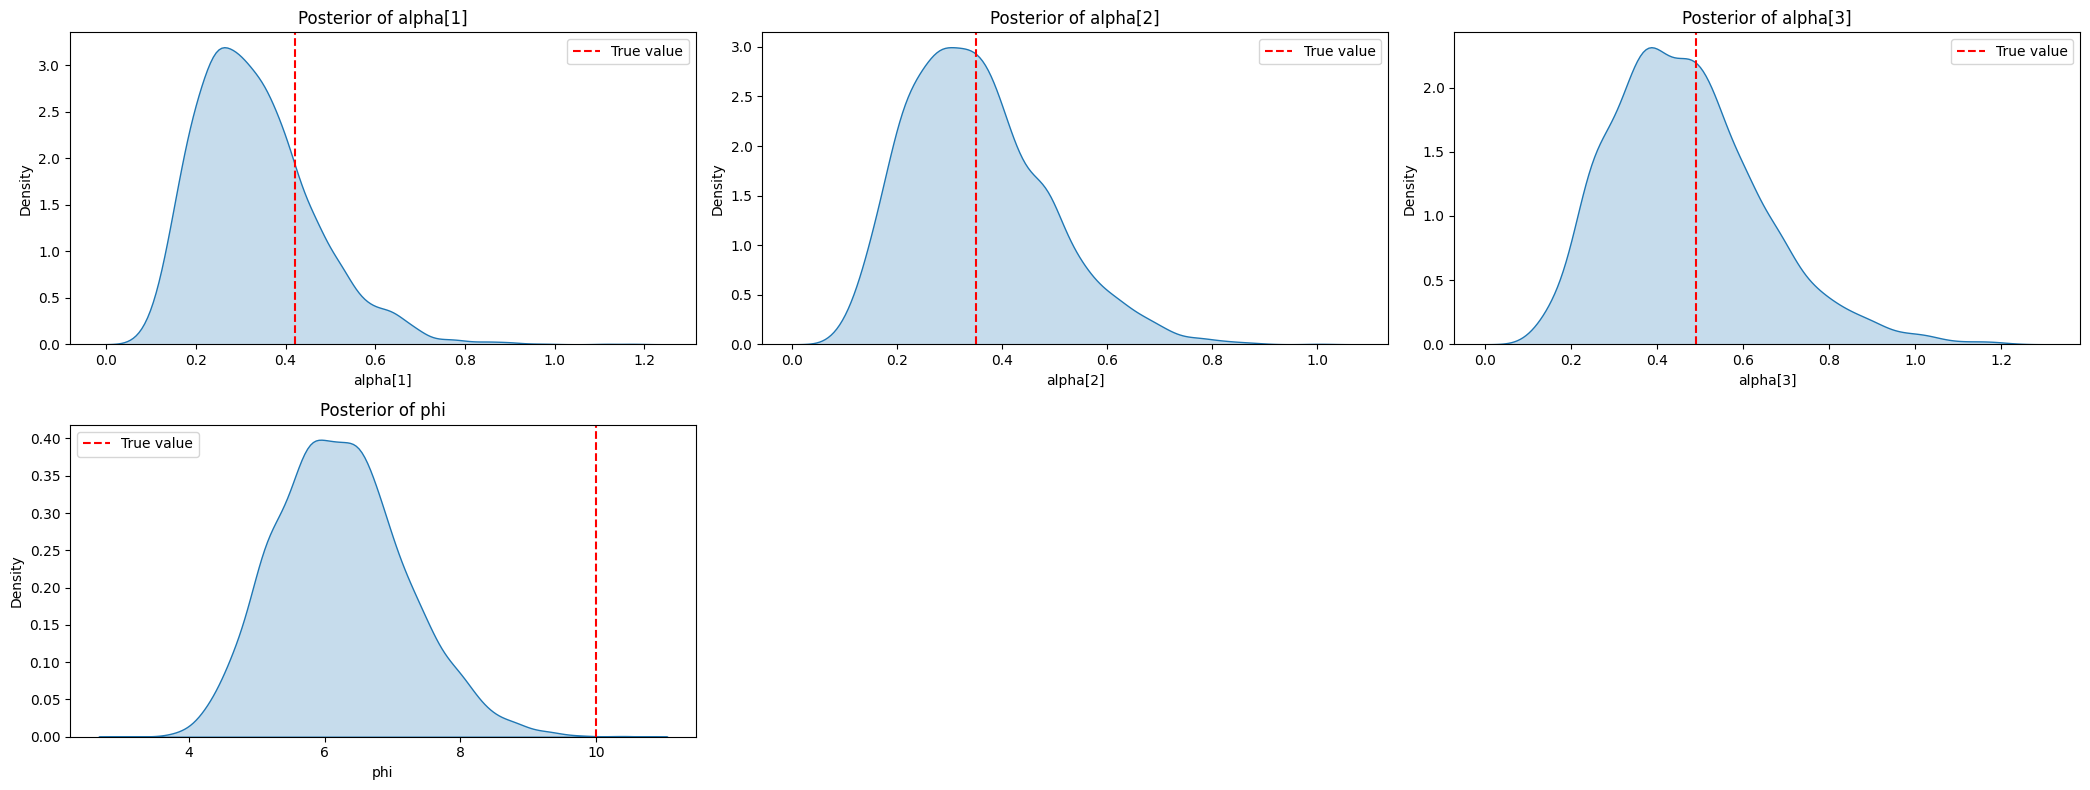

In [ ]:
parameters1 = ['phi']
t1 = {'phi': phi}


plot_posterior_kde_grid(fit_multi_model, parameters=parameters1, 
                        n_cols=3, true_values=t1, save = 'Checks_for_alphaPhi')

# PRIOR PREDICTIVE CHECK

In [ ]:

model_prior = CmdStanModel(stan_file = 'stan files/multi_patch_PRIOR.stan')
prior_check = model_prior.sample(data = seir_data,
                                     iter_sampling = 1000,
                                     chains = 4,
                                     seed = 0)

chain 1 |          | 00:00 Status


chain 1 |▉         | 00:18 Iteration:    1 / 2000 [  0%]  (Warmup)


chain 1 |█▎        | 01:41 Iteration:  100 / 2000 [  5%]  (Warmup)

chain 1 |█▊        | 02:10 Iteration:  200 / 2000 [ 10%]  (Warmup)
chain 1 |██▎       | 02:14 Iteration:  300 / 2000 [ 15%]  (Warmup)




















chain 1 |██▋       | 08:19 Iteration:  400 / 2000 [ 20%]  (Warmup)

chain 1 |███▏      | 08:22 Iteration:  500 / 2000 [ 25%]  (Warmup)

chain 1 |███▋      | 08:27 Iteration:  600 / 2000 [ 30%]  (Warmup)

chain 1 |████      | 08:42 Iteration:  700 / 2000 [ 35%]  (Warmup)

chain 1 |████▌     | 08:44 Iteration:  800 / 2000 [ 40%]  (Warmup)

chain 1 |█████▍    | 08:56 Iteration: 1000 / 2000 [ 50%]  (Warmup)

chain 1 |████████▏ | 09:34 Iteration: 1500 / 2000 [ 75%]  (Sampling)

chain 1 |████████▋ | 09:40 Iteration: 1600 / 2000 [ 80%]  (Sampling)

chain 1 |█████████ | 09:55 Iteration: 1700 / 2000 [ 85%]  (Sampling)

chain 1 |█████████▌| 09:58 Iteration: 1800 / 2000 [ 90%

In [ ]:
import math
def plot_prior(model, param_names, boundary, ncols=3, 
               figsize_per_plot=(8, 7), 
               sharey=True, 
               legend_on_first=True):
    

    countries = ['Guinea','Liberia','Sierra Leone']
    n_params = len(param_names)
    nrows   = math.ceil(n_params / ncols)
    fig_w   = figsize_per_plot[0] * ncols
    fig_h   = figsize_per_plot[1] * nrows+1
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h))
    
    # flatten even if nrows or ncols == 1
    axes = np.array(axes).reshape(-1)
    
    for i, (ax, pname) in enumerate(zip(axes, param_names)):
        # pull samples: shape (n_samples, n_patches)
        samples = model.stan_variable(pname)
        df = pd.DataFrame(samples, columns=countries)
        
        # plot densities
        df.plot(kind='density', ax=ax, legend=False)
        ax.set_title(f'Prior predictive check for {pname}')
        ax.set_xlabel(pname)
        ax.grid(True)
        ax.axvline(x=boundary[i*2], color='r')
        ax.axvline(x=boundary[i*2+1], color='r')
    
    # hide any unused axes
    for ax in axes[n_params:]:
        ax.set_visible(False)

    
    # add legend if desired
    if legend_on_first and n_params > 0:
        axes[0].legend(countries, title='Patch')
    
    plt.tight_layout()
    return fig, axes


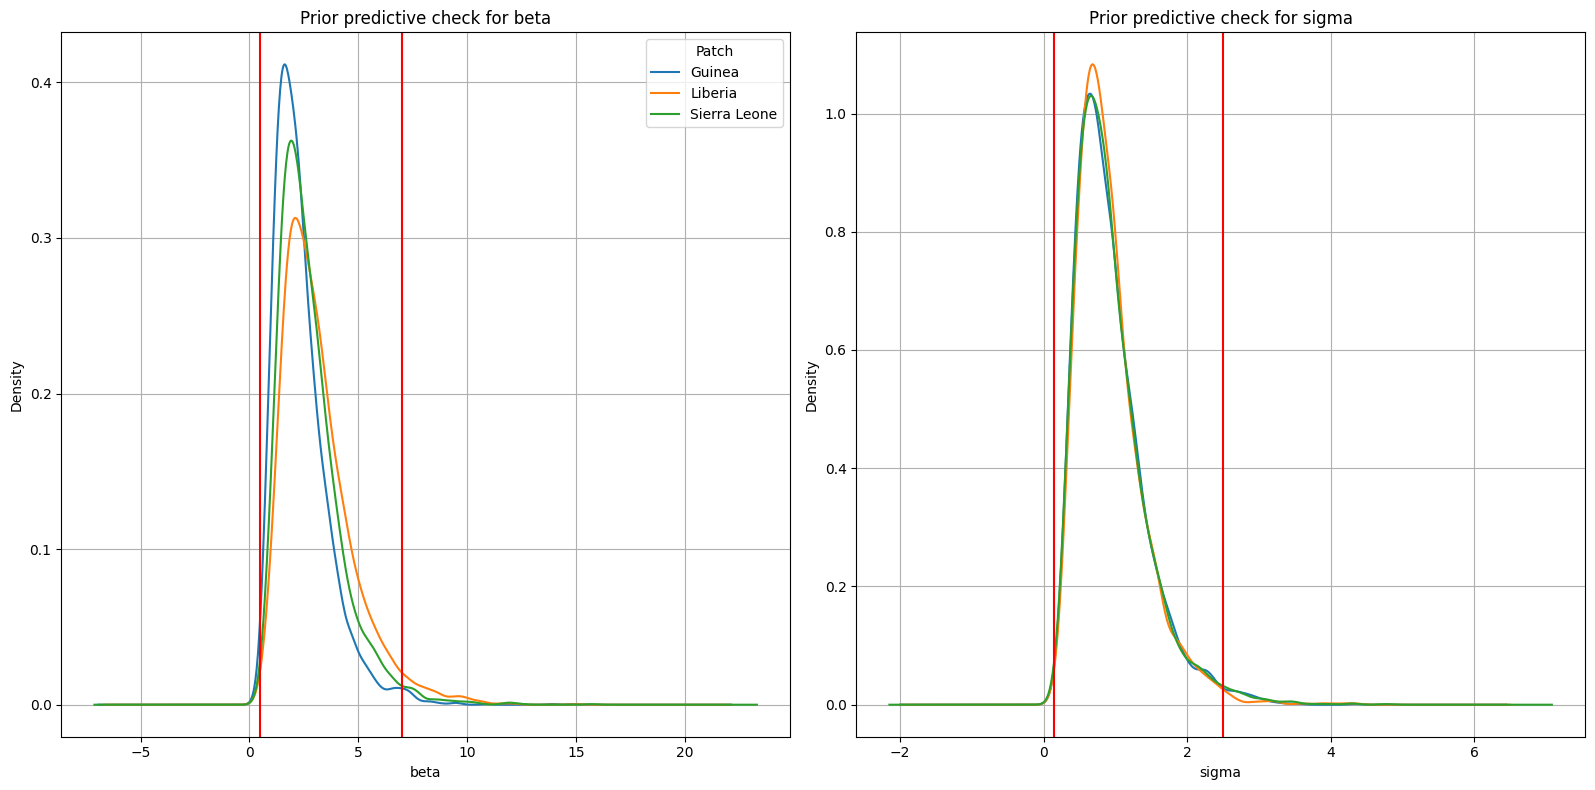

In [ ]:
params = ['beta','sigma', 'gamma']
boundaries = [0.5, 7, 0.14, 2.5, 0.1, 2.0]

# 5 parameters → grid of 2×3 (since ncols=3)
fig, axes = plot_prior(prior_check, params, boundary = boundaries, ncols=3)
plt.show()

In [ ]:
# infection_draws = prior_check.draws_pd("y")
# lines = plt.plot(range(1,15),
#                  infection_draws,
#                  color = "k", alpha = 0.1)
# plt.axhline(y=N[0], color='r', linestyle='--')
# plt.xlabel('Time')
# plt.ylabel('Number of infections')
# plt.show()

# R0

from sympy import *
init_printing()